In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from scenario_creator import create_env
from senario_multi_gnodeb import scenarios
from senario_multi_gnodeb import scenario_3gnb_overlap_large
# --- choose the 3-gNB scenario ---
sc = scenario_3gnb_overlap_large
def scenario_to_gnb_configs(scenario_dict):
    gnb_configs = []
    positions = scenario_dict["gnb_positions"]
    radii = scenario_dict["coverage_radius"]
    carriers = scenario_dict["carrier_ids"]
    max_prbs = scenario_dict["max_prbs_per_gnb"]
    scenario_priorities = scenario_dict.get("slice_priorities", {})

    for i, ((x, y), r, c, p) in enumerate(zip(positions, radii, carriers, max_prbs)):
        gnb_configs.append({
            "id": i,
            "x": x,
            "y": y,
            "coverage_radius": r,
            "carrier_id": c,
            "n_prbs": p,
            "slice_priorities": scenario_priorities.get(i, None),
        })
    return gnb_configs

rng = np.random.default_rng(7)
gnb_configs = scenario_to_gnb_configs(sc)

env = create_env(
    rng=rng,
    n=1,
    multi_gnb=True,
    gnb_configs=gnb_configs,
    slots_per_step=10,
    coverage_radius=350,
    handover_hysteresis=0.5,
    handover_ttt=2,
    outage_penalty=1.0,
    handover_penalty=0.1,
    use_mean_gnb_reward=True,
    verbose=False,
    step_dt=1.0,
    max_episode_steps=200
)

# Put 10 moving UEs near the overlap region
# only eMBB / URLLC here to avoid the mMTC object mismatch
ue_specs = [
    (170, 130,  4.0,  1.0, "eMBB", 1_000_000),
    (220, 120, -3.0,  2.0, "URLLC", 1_500_000),
    (250, 160,  2.5, -2.0, "eMBB", 900_000),
    (180, 220,  1.5, -3.0, "URLLC", 2_000_000),
    (300, 140, -2.0,  1.5, "eMBB", 1_200_000),
    (210, 260,  3.0, -1.5, "eMBB", 800_000),
    (140, 180,  2.0,  2.5, "URLLC", 1_800_000),
    (260, 240, -2.5, -1.0, "eMBB", 1_100_000),
    (320, 200, -3.5,  0.5, "URLLC", 1_600_000),
    (200, 300,  1.0, -2.5, "eMBB", 950_000),
]

for x, y, vx, vy, slice_type, bit_rate in ue_specs:
    env.add_ue(
        x=float(x),
        y=float(y),
        vx=float(vx),
        vy=float(vy),
        slice_type=slice_type,
        bit_rate=float(bit_rate),
    )

obs, info = env.reset(seed=123)

print("n_gnbs:", env.n_gnbs)
print("n_ues:", len(env.get_all_ues()))
print("initial control ue:", env._current_control_ue_id)
print("initial connected:", info["n_connected_ues"], "/", info["n_tracked_ues"])

n_gnbs: 3
n_ues: 10
initial control ue: 0
initial connected: 10 / 10


In [2]:
plt.show()
for gnb in env.gnbs:
    print(f"\ngNB {gnb.id}")
    for ue in env.get_all_ues()[:3]:
        m = env._compute_link_metrics(gnb, ue)
        print(
            f"UE {ue.id}: rx={m['rx_power_dbm']:.2f} dBm, "
            f"noise={m['noise_dbm']:.2f} dBm, "
            f"interf={m['interference_dbm']:.2f} dBm, "
            f"snr={m['snr_db']:.2f} dB, "
            f"sinr={m['sinr_db']:.2f} dB"
        )


gNB 0
UE 0: rx=-84.45 dBm, noise=-114.45 dBm, interf=-inf dBm, snr=30.00 dB, sinr=30.00 dB
UE 1: rx=-78.87 dBm, noise=-114.45 dBm, interf=-inf dBm, snr=35.58 dB, sinr=35.58 dB
UE 2: rx=-88.80 dBm, noise=-114.45 dBm, interf=-inf dBm, snr=25.65 dB, sinr=25.65 dB

gNB 1
UE 0: rx=-inf dBm, noise=-114.45 dBm, interf=-inf dBm, snr=-inf dB, sinr=-inf dB
UE 1: rx=-inf dBm, noise=-114.45 dBm, interf=-inf dBm, snr=-inf dB, sinr=-inf dB
UE 2: rx=-inf dBm, noise=-114.45 dBm, interf=-inf dBm, snr=-inf dB, sinr=-inf dB

gNB 2
UE 0: rx=-inf dBm, noise=-114.45 dBm, interf=-inf dBm, snr=-inf dB, sinr=-inf dB
UE 1: rx=-inf dBm, noise=-114.45 dBm, interf=-inf dBm, snr=-inf dB, sinr=-inf dB
UE 2: rx=-inf dBm, noise=-114.45 dBm, interf=-inf dBm, snr=-inf dB, sinr=-inf dB


In [3]:
import pandas as pd
import numpy as np

rows = []

for step in range(80):
    scores_before = {ue.id: env._compute_ue_badness(ue) for ue in env.get_all_ues()}
    worst_before = max(scores_before, key=scores_before.get)

    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    for ue in env.get_all_ues():
        rows.append({
            "step": step + 1,
            "ue_id": ue.id,
            "x": float(ue.x),
            "y": float(ue.y),
            "serving_gnb": -1 if ue.serving_gnb is None else int(ue.serving_gnb),
            "connected": int(bool(ue.connected)),
            "sinr": float(ue.e_sinr) if np.isfinite(ue.e_sinr) else np.nan,
            "queue": float(ue.queue),
            "throughput": float(ue.th),
            "ho_pending": int(bool(ue.ho_pending)),
            "reward": float(reward),
            "acted_ue_id": info.get("acted_ue_id"),
            "next_control_ue_id": info.get("next_control_ue_id"),
            "worst_before": worst_before,
            "requested_target_gnb": info.get("requested_target_gnb"),
            "serving_before": info.get("serving_gnb_before"),
            "serving_after": info.get("serving_gnb_after"),
        })

    if terminated or truncated:
        print("Episode ended at step", step + 1)
        break

df = pd.DataFrame(rows)

print("Rows:", len(df))
print("Handovers:", len(env.get_handover_events()))
print("Worst-UE match rate:",
      (df.drop_duplicates('step')["acted_ue_id"].values == df.drop_duplicates('step')["worst_before"].values).mean())

display(df.head())

Rows: 800
Handovers: 0
Worst-UE match rate: 1.0


,step,ue_id,x,y,serving_gnb,connected,sinr,queue,throughput,ho_pending,reward,acted_ue_id,next_control_ue_id,worst_before,requested_target_gnb,serving_before,serving_after
0,1,0,174.0,131.0,0,1,36.358873,0.0,230764.552617,0,0.172383,0,2,0,0,0,0
1,1,1,217.0,122.0,0,1,32.966745,0.0,345600.000000,0,0.172383,0,2,0,0,0,0
2,1,2,252.5,158.0,0,1,31.309680,0.0,201675.948997,0,0.172383,0,2,0,0,0,0
3,1,3,181.5,217.0,0,1,34.842999,0.0,461128.842072,0,0.172383,0,2,0,0,0,0
4,1,4,298.0,141.5,0,1,24.047160,0.0,287991.142076,0,0.172383,0,2,0,0,0,0


In [4]:
step_df = df.drop_duplicates("step").copy()

print("Connected UEs by step:")
display(df.groupby("step")["connected"].sum().head(10))

print("Serving gNB distribution:")
display(df["serving_gnb"].value_counts().sort_index())

print("Per-step acted UE / worst UE:")
display(step_df[["step", "acted_ue_id", "worst_before", "next_control_ue_id", "reward"]].head(15))

print("Handover events:")
display(pd.DataFrame(env.get_handover_events()))

Connected UEs by step:


step
1     10
2     10
3     10
4     10
5     10
6     10
7     10
8     10
9     10
10    10
Name: connected, dtype: int64

Serving gNB distribution:


serving_gnb
0    800
Name: count, dtype: int64

Per-step acted UE / worst UE:


,step,acted_ue_id,worst_before,next_control_ue_id,reward
0,1,0,0,2,0.172383
10,2,2,2,2,0.216343
20,3,2,2,2,0.259164
30,4,2,2,8,0.288457
40,5,8,8,2,1.266279
50,6,2,2,2,0.337671
60,7,2,2,2,0.350330
70,8,2,2,5,0.369712
80,9,5,5,5,0.370536
90,10,5,5,5,0.370884


Handover events:


""


In [5]:
import numpy as np
import pandas as pd

obs, info = env.reset(seed=123)

rows = []
handover_rows = []

n_steps = 80

for step in range(n_steps):
    scores_before = {ue.id: env._compute_ue_badness(ue) for ue in env.get_all_ues()}
    worst_before = max(scores_before, key=scores_before.get)

    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    for ue in env.get_all_ues():
        rows.append({
            "step": step + 1,
            "ue_id": ue.id,
            "x": float(ue.x),
            "y": float(ue.y),
            "vx": float(ue.vx),
            "vy": float(ue.vy),
            "serving_gnb": -1 if ue.serving_gnb is None else int(ue.serving_gnb),
            "connected": int(bool(ue.connected)),
            "sinr": float(ue.e_sinr) if np.isfinite(ue.e_sinr) else np.nan,
            "snr": float(ue.e_snr) if np.isfinite(ue.e_snr) else np.nan,
            "queue": float(ue.queue),
            "throughput": float(ue.th),
            "wait_time": float(ue.wait_time),
            "ho_pending": int(bool(ue.ho_pending)),
            "badness": float(env._compute_ue_badness(ue)),
            "reward": float(reward),
            "acted_ue_id": info.get("acted_ue_id"),
            "next_control_ue_id": info.get("next_control_ue_id"),
            "worst_before": worst_before,
            "requested_target_gnb": info.get("requested_target_gnb"),
            "serving_before": info.get("serving_gnb_before"),
            "serving_after": info.get("serving_gnb_after"),
        })

    if terminated or truncated:
        print("Episode ended at step", step + 1)
        break

df = pd.DataFrame(rows)
ho_df = pd.DataFrame(env.get_handover_events())

print("rows:", len(df))
print("steps:", df["step"].nunique())
print("UEs:", df["ue_id"].nunique())
print("handovers:", len(ho_df))
display(df.head())
display(ho_df.head() if not ho_df.empty else pd.DataFrame({"msg": ["No handovers"]}))

rows: 800
steps: 80
UEs: 10
handovers: 3


,step,ue_id,x,y,vx,vy,serving_gnb,connected,sinr,snr,...,wait_time,ho_pending,badness,reward,acted_ue_id,next_control_ue_id,worst_before,requested_target_gnb,serving_before,serving_after
0,1,0,494.0,211.0,4.0,1.0,0,1,13.198779,13.198779,...,1.0,0,357.816788,1.045381,6,2,6,2,0,0
1,1,1,-23.0,282.0,-3.0,2.0,0,1,29.425592,29.425592,...,1.0,0,16.544000,1.045381,6,2,6,2,0,0
2,1,2,452.5,-2.0,2.5,-2.0,0,1,-3.103359,21.280710,...,1.0,0,10137.454575,1.045381,6,2,6,2,0,0
3,1,3,301.5,-23.0,1.5,-3.0,0,1,33.665721,33.665721,...,1.0,0,15.391110,1.045381,6,2,6,2,0,0
4,1,4,138.0,261.5,-2.0,1.5,0,1,36.855625,36.855625,...,1.0,0,17.117014,1.045381,6,2,6,2,0,0


,step,ue_id,from_gnb,to_gnb
0,43,0,0,1
1,51,6,0,2
2,69,5,0,1


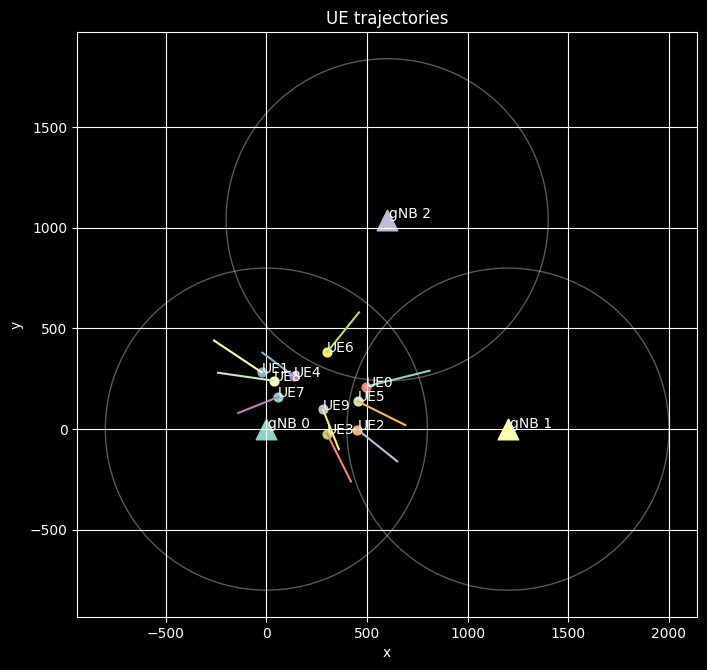

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(8, 8))

for gnb in env.gnbs:
    ax.scatter(gnb.x, gnb.y, s=220, marker="^")
    ax.add_patch(Circle((gnb.x, gnb.y), gnb.coverage_radius, fill=False, alpha=0.35))
    ax.text(gnb.x + 8, gnb.y + 8, f"gNB {gnb.id}")

for ue_id in sorted(df["ue_id"].unique()):
    d = df[df["ue_id"] == ue_id]
    ax.plot(d["x"], d["y"], linewidth=1.5)
    ax.scatter(d["x"].iloc[0], d["y"].iloc[0], s=40)
    ax.text(d["x"].iloc[0], d["y"].iloc[0], f"UE{ue_id}")

ax.set_title("UE trajectories")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.grid(True)
plt.show()

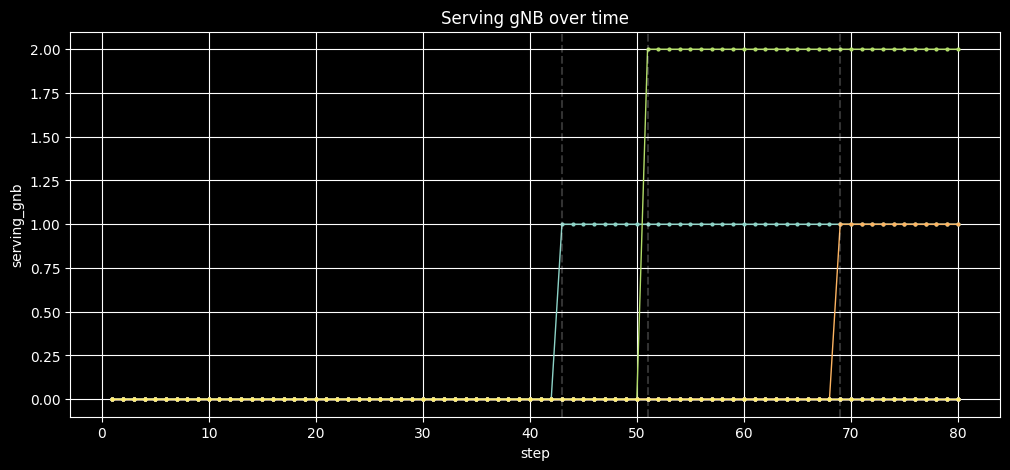

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

for ue_id in sorted(df["ue_id"].unique()):
    d = df[df["ue_id"] == ue_id]
    ax.plot(d["step"], d["serving_gnb"], marker="o", markersize=2, linewidth=1, label=f"UE{ue_id}")

if not ho_df.empty:
    for _, r in ho_df.iterrows():
        ax.axvline(r["step"], linestyle="--", alpha=0.2)

ax.set_title("Serving gNB over time")
ax.set_xlabel("step")
ax.set_ylabel("serving_gnb")
ax.grid(True)
plt.show()

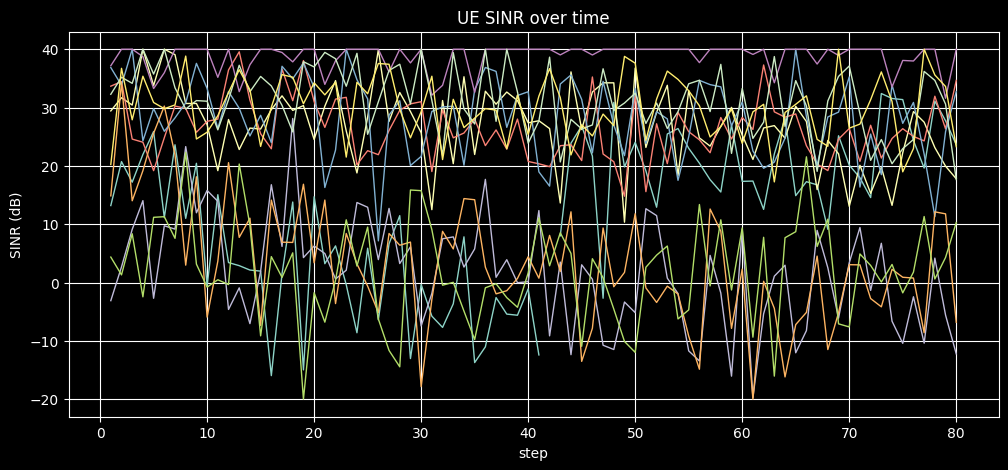

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

for ue_id in sorted(df["ue_id"].unique()):
    d = df[df["ue_id"] == ue_id]
    ax.plot(d["step"], d["sinr"], linewidth=1, label=f"UE{ue_id}")

ax.set_title("UE SINR over time")
ax.set_xlabel("step")
ax.set_ylabel("SINR (dB)")
ax.grid(True)
plt.show()

In [9]:
for gnb in env.gnbs:
    print(f"\ngNB {gnb.id}")
    for ue in env.get_all_ues()[:3]:
        m = env._compute_link_metrics(gnb, ue)
        print(
            f"UE {ue.id}: rx={m['rx_power_dbm']:.2f} dBm, "
            f"noise={m['noise_dbm']:.2f} dBm, "
            f"interf={m['interference_dbm']:.2f} dBm, "
            f"snr={m['snr_db']:.2f} dB, "
            f"sinr={m['sinr_db']:.2f} dB"
        )


gNB 0
UE 0: rx=-inf dBm, noise=-114.45 dBm, interf=-inf dBm, snr=-inf dB, sinr=-inf dB
UE 1: rx=-82.23 dBm, noise=-114.45 dBm, interf=-inf dBm, snr=32.21 dB, sinr=32.21 dB
UE 2: rx=-90.74 dBm, noise=-114.45 dBm, interf=-93.80 dBm, snr=23.70 dB, sinr=3.02 dB

gNB 1
UE 0: rx=-91.39 dBm, noise=-114.45 dBm, interf=-inf dBm, snr=23.06 dB, sinr=23.06 dB
UE 1: rx=-inf dBm, noise=-114.45 dBm, interf=-inf dBm, snr=-inf dB, sinr=-inf dB
UE 2: rx=-88.66 dBm, noise=-114.45 dBm, interf=-93.28 dBm, snr=25.79 dB, sinr=4.59 dB

gNB 2
UE 0: rx=-inf dBm, noise=-114.45 dBm, interf=-inf dBm, snr=-inf dB, sinr=-inf dB
UE 1: rx=-inf dBm, noise=-114.45 dBm, interf=-inf dBm, snr=-inf dB, sinr=-inf dB
UE 2: rx=-inf dBm, noise=-114.45 dBm, interf=-inf dBm, snr=-inf dB, sinr=-inf dB


# Test 4 gnodeB senario

In [10]:
import numpy as np
from scenario_creator import create_env

scenario_4gnb_mixed = {
    'n_gnbs': 4,
    'max_prbs_per_gnb': [150, 150, 150, 150],
    'gnb_positions': [
        (0.0, 0.0),
        (900.0, 0.0),
        (450.0, 780.0),
        (1650.0, 250.0),
    ],
    'coverage_radius': [700.0, 700.0, 700.0, 650.0],
    'carrier_ids': [0, 0, 0, 0],
    'n_ues': 200,
    'ue_distribution': 'clustered',
    'slices': [
        {'type': 'eMBB', 'count': 2},
        {'type': 'mMTC', 'count': 1},
        {'type': 'URLLC', 'count': 1},
    ]
}

def scenario_to_gnb_configs(scenario_dict):
    gnb_configs = []
    positions = scenario_dict["gnb_positions"]
    radii = scenario_dict["coverage_radius"]
    carriers = scenario_dict["carrier_ids"]
    max_prbs = scenario_dict["max_prbs_per_gnb"]

    for i, ((x, y), r, c, p) in enumerate(zip(positions, radii, carriers, max_prbs)):
        gnb_configs.append({
            "id": i,
            "x": x,
            "y": y,
            "coverage_radius": r,
            "carrier_id": c,
            "n_prbs": p,
            "tx_power_dbm": 23.0,
        })
    return gnb_configs

rng = np.random.default_rng(7)
gnb_configs = scenario_to_gnb_configs(scenario_4gnb_mixed)

env = create_env(
    rng=rng,
    n=1,
    multi_gnb=True,
    gnb_configs=gnb_configs,
    slots_per_step=10,
    coverage_radius=700,
    handover_hysteresis=1.0,
    handover_ttt=2,
    outage_penalty=1.0,
    handover_penalty=0.1,
    use_mean_gnb_reward=True,
    verbose=False,
    step_dt=1.0,
    max_episode_steps=200,
)

# Put UEs mostly in the main overlap zone, with a few closer to gNB 3
ue_specs = [
    (200, 150,  6.0,  1.0, "eMBB"),
    (500, 180, -4.0,  2.0, "URLLC"),
    (420, 420,  3.0, -3.0, "eMBB"),
    (650, 250, -2.0,  1.0, "URLLC"),
    (300, 500,  2.0, -2.0, "eMBB"),
    (800, 200,  4.0,  0.5, "URLLC"),
    (1000, 250, 5.0,  0.0, "eMBB"),
    (1200, 280, 4.0, -0.5, "URLLC"),
    (1400, 300, 2.0,  0.0, "eMBB"),
    (1500, 350, 1.5, -1.0, "URLLC"),
]

for x, y, vx, vy, slice_type in ue_specs:
    env.add_ue(
        x=float(x),
        y=float(y),
        vx=float(vx),
        vy=float(vy),
        slice_type=slice_type,
        bit_rate=1_000_000.0,
    )

obs, info = env.reset(seed=123)
print("n_gnbs:", env.n_gnbs)
print("connected:", info["n_connected_ues"], "/", info["n_tracked_ues"])
print("initial control ue:", env._current_control_ue_id)

n_gnbs: 4
connected: 10 / 10
initial control ue: 1


In [11]:
import numpy as np
from scenario_creator import create_env

scenario_4gnb_mixed = {
    'n_gnbs': 4,
    'max_prbs_per_gnb': [150, 150, 150, 150],
    'gnb_positions': [
        (0.0, 0.0),
        (900.0, 0.0),
        (450.0, 780.0),
        (1650.0, 250.0),
    ],
    'coverage_radius': [700.0, 700.0, 700.0, 650.0],
    'carrier_ids': [0, 0, 0, 0],
    'n_ues': 200,
    'ue_distribution': 'clustered',
    'slices': [
        {'type': 'eMBB', 'count': 2},
        {'type': 'mMTC', 'count': 1},
        {'type': 'URLLC', 'count': 1},
    ]
}

def scenario_to_gnb_configs(scenario_dict):
    gnb_configs = []
    for i, ((x, y), r, c, p) in enumerate(zip(
        scenario_dict["gnb_positions"],
        scenario_dict["coverage_radius"],
        scenario_dict["carrier_ids"],
        scenario_dict["max_prbs_per_gnb"],
    )):
        gnb_configs.append({
            "id": i,
            "x": x,
            "y": y,
            "coverage_radius": r,
            "carrier_id": c,
            "n_prbs": p,
            "tx_power_dbm": 23.0,
        })
    return gnb_configs

rng = np.random.default_rng(7)
gnb_configs = scenario_to_gnb_configs(scenario_4gnb_mixed)

env = create_env(
    rng=rng,
    n=1,
    multi_gnb=True,
    gnb_configs=gnb_configs,
    slots_per_step=10,
    coverage_radius=700,
    handover_hysteresis=1.0,
    handover_ttt=2,
    outage_penalty=1.0,
    handover_penalty=0.1,
    use_mean_gnb_reward=True,
    verbose=False,
    step_dt=1.0,
    max_episode_steps=200,
)

# Better placement:
# 6 UEs start in the triangle overlap and move generally to the right toward gNB 3
# 2 UEs start mid-way between triangle and gNB 3
# 2 UEs start closer to gNB 3 region
ue_specs = [
    # overlap zone -> moving toward gNB 3
    (320, 180,  7.0,  0.8, "eMBB",  1_000_000),
    (430, 140,  6.5,  1.2, "URLLC", 1_500_000),
    (520, 220,  6.0,  0.5, "eMBB",    900_000),
    (350, 320,  5.5, -0.5, "URLLC", 1_800_000),
    (470, 360,  6.8, -1.0, "eMBB",  1_100_000),
    (540, 420,  5.8, -1.3, "URLLC", 1_300_000),

    # transition zone
    (850, 220,  5.0,  0.2, "eMBB",  1_000_000),
    (980, 260,  4.5, -0.3, "URLLC", 1_400_000),

    # near gNB 3
    (1350, 280, 2.0,  0.0, "eMBB",  1_000_000),
    (1450, 340, 1.5, -0.6, "URLLC", 1_200_000),
]

for x, y, vx, vy, slice_type, bit_rate in ue_specs:
    env.add_ue(
        x=float(x),
        y=float(y),
        vx=float(vx),
        vy=float(vy),
        slice_type=slice_type,
        bit_rate=float(bit_rate),
    )

obs, info = env.reset(seed=123)
print("n_gnbs:", env.n_gnbs)
print("connected:", info["n_connected_ues"], "/", info["n_tracked_ues"])
print("initial control ue:", env._current_control_ue_id)

n_gnbs: 4
connected: 10 / 10
initial control ue: 3


In [12]:
import pandas as pd
import numpy as np

rows = []
n_steps = 120

obs, info = env.reset(seed=123)

for step in range(n_steps):
    scores_before = {ue.id: env._compute_ue_badness(ue) for ue in env.get_all_ues()}
    worst_before = max(scores_before, key=scores_before.get)

    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    for ue in env.get_all_ues():
        metrics = env.get_ue_radio_metrics(ue.id)
        rows.append({
            "step": step + 1,
            "ue_id": ue.id,
            "x": float(ue.x),
            "y": float(ue.y),
            "vx": float(ue.vx),
            "vy": float(ue.vy),
            "serving_gnb": -1 if ue.serving_gnb is None else int(ue.serving_gnb),
            "connected": int(bool(ue.connected)),
            "sinr": float(metrics["sinr_db"]) if np.isfinite(metrics["sinr_db"]) else np.nan,
            "snr": float(metrics["snr_db"]) if np.isfinite(metrics["snr_db"]) else np.nan,
            "interference_dbm": float(metrics["interference_dbm"]) if np.isfinite(metrics["interference_dbm"]) else np.nan,
            "queue": float(ue.queue),
            "throughput": float(ue.th),
            "ho_pending": int(bool(ue.ho_pending)),
            "acted_ue_id": info.get("acted_ue_id"),
            "next_control_ue_id": info.get("next_control_ue_id"),
            "worst_before": worst_before,
            "reward": float(reward),
        })

    if terminated or truncated:
        print("Episode ended at step", step + 1)
        break

df = pd.DataFrame(rows)
ho_df = pd.DataFrame(env.get_handover_events())

print("rows:", len(df))
print("steps:", df["step"].nunique())
print("handovers:", len(ho_df))
display(df.head())
display(ho_df.head() if not ho_df.empty else pd.DataFrame({"msg": ["No handovers"]}))

rows: 1200
steps: 120
handovers: 6


,step,ue_id,x,y,vx,vy,serving_gnb,connected,sinr,snr,interference_dbm,queue,throughput,ho_pending,acted_ue_id,next_control_ue_id,worst_before,reward
0,1,0,327.0,180.8,7.0,0.8,0,1,10.073373,19.967028,-105.023172,10993178.0,124.203841,0,5,3,5,0.766804
1,1,1,436.5,141.2,6.5,1.2,0,1,-5.733460,17.560175,-91.174031,16447114.0,945.375471,0,5,3,5,0.766804
2,1,2,526.0,220.5,6.0,0.5,0,1,-4.957131,9.641015,-100.002454,9885796.0,252.226876,0,5,3,5,0.766804
3,1,3,355.5,319.5,5.5,-0.5,0,1,4.743653,17.564325,-101.859580,18685935.0,22236.513083,0,5,3,5,0.766804
4,1,4,476.8,359.0,6.8,-1.0,2,1,11.446098,27.551506,-98.449668,3107510.0,179762.419338,0,5,3,5,0.766804


,step,ue_id,from_gnb,to_gnb
0,7,2,0,1
1,9,1,0,1
2,32,3,0,1
3,36,0,0,1
4,79,4,2,1


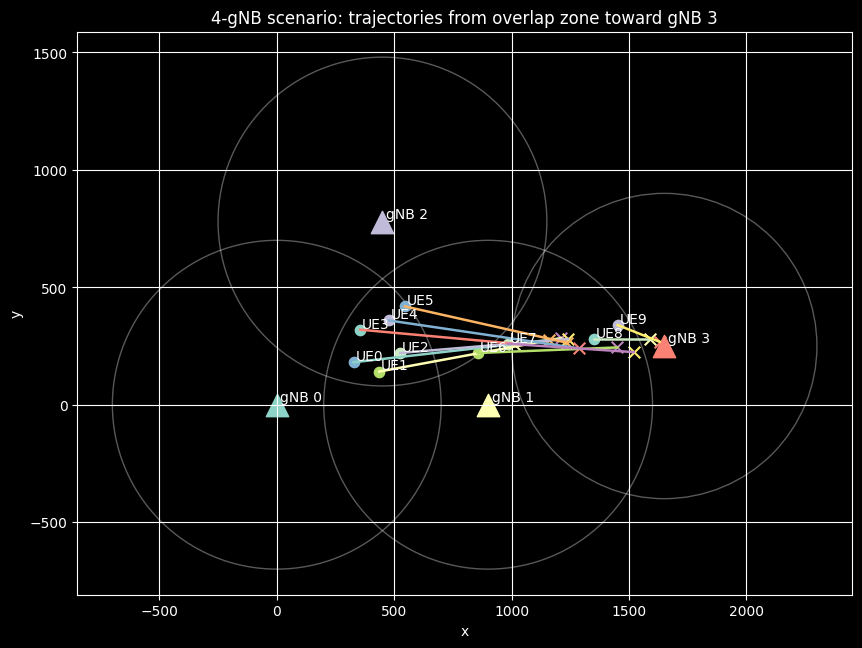

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(10, 8))

# gNBs
for gnb in env.gnbs:
    ax.scatter(gnb.x, gnb.y, s=260, marker="^")
    ax.add_patch(Circle((gnb.x, gnb.y), gnb.coverage_radius, fill=False, alpha=0.35))
    ax.text(gnb.x + 15, gnb.y + 15, f"gNB {gnb.id}", fontsize=10)

# trajectories
for ue_id in sorted(df["ue_id"].unique()):
    d = df[df["ue_id"] == ue_id].sort_values("step")
    ax.plot(d["x"], d["y"], linewidth=1.8)
    ax.scatter(d["x"].iloc[0], d["y"].iloc[0], s=55)   # start
    ax.scatter(d["x"].iloc[-1], d["y"].iloc[-1], s=70, marker="x")  # end
    ax.text(d["x"].iloc[0] + 8, d["y"].iloc[0] + 8, f"UE{ue_id}")

ax.set_title("4-gNB scenario: trajectories from overlap zone toward gNB 3")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.grid(True)
plt.show()

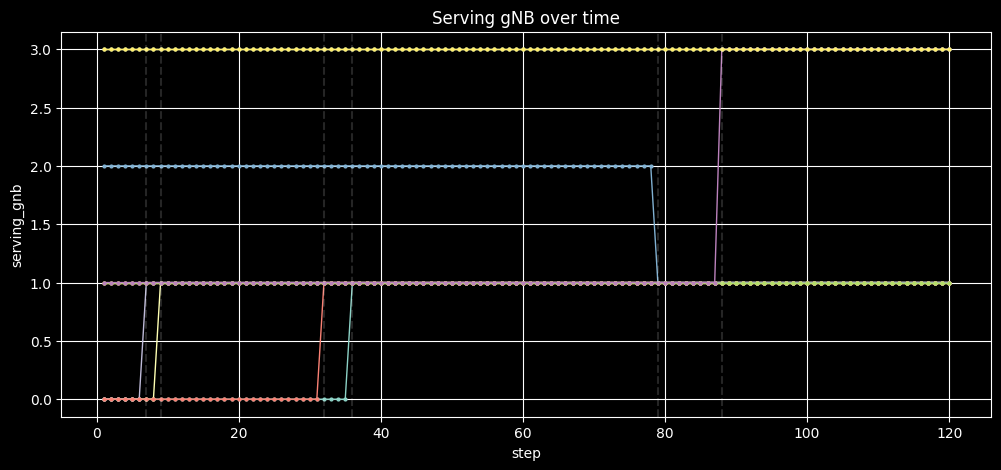

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

for ue_id in sorted(df["ue_id"].unique()):
    d = df[df["ue_id"] == ue_id].sort_values("step")
    ax.plot(d["step"], d["serving_gnb"], marker="o", markersize=2, linewidth=1, label=f"UE{ue_id}")

if not ho_df.empty:
    for _, r in ho_df.iterrows():
        ax.axvline(r["step"], linestyle="--", alpha=0.15)

ax.set_title("Serving gNB over time")
ax.set_xlabel("step")
ax.set_ylabel("serving_gnb")
ax.grid(True)
plt.show()

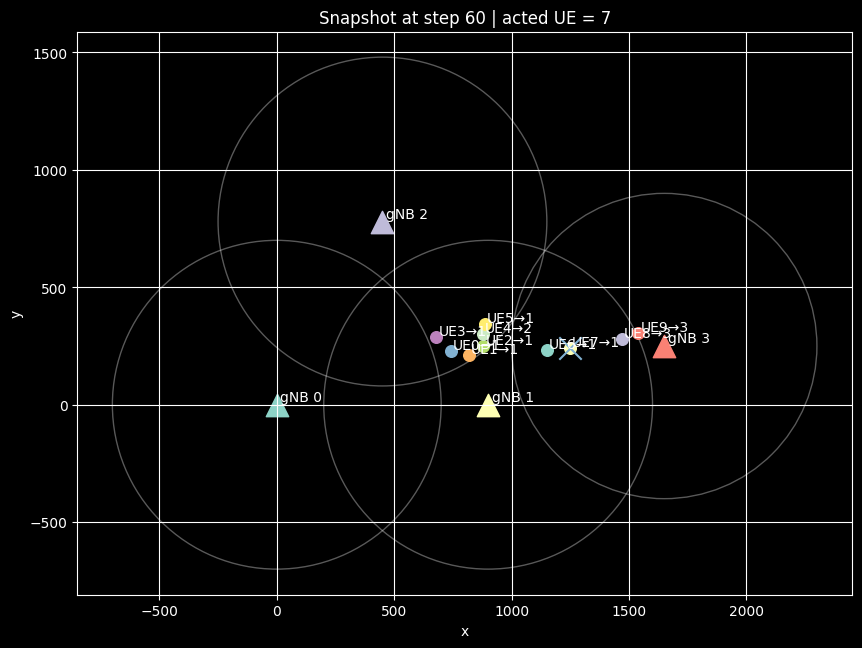

In [15]:
from matplotlib.patches import Circle

step_to_plot = 60
snap = df[df["step"] == step_to_plot].copy()

fig, ax = plt.subplots(figsize=(10, 8))

for gnb in env.gnbs:
    ax.scatter(gnb.x, gnb.y, s=260, marker="^")
    ax.add_patch(Circle((gnb.x, gnb.y), gnb.coverage_radius, fill=False, alpha=0.35))
    ax.text(gnb.x + 15, gnb.y + 15, f"gNB {gnb.id}")

for _, r in snap.iterrows():
    ax.scatter(r["x"], r["y"], s=70)
    ax.text(r["x"] + 8, r["y"] + 8, f'UE{int(r["ue_id"])}→{int(r["serving_gnb"])}')

acted = int(snap["acted_ue_id"].iloc[0])
acted_row = snap[snap["ue_id"] == acted].iloc[0]
ax.scatter(acted_row["x"], acted_row["y"], s=260, marker="x")

ax.set_title(f"Snapshot at step {step_to_plot} | acted UE = {acted}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.grid(True)
plt.show()

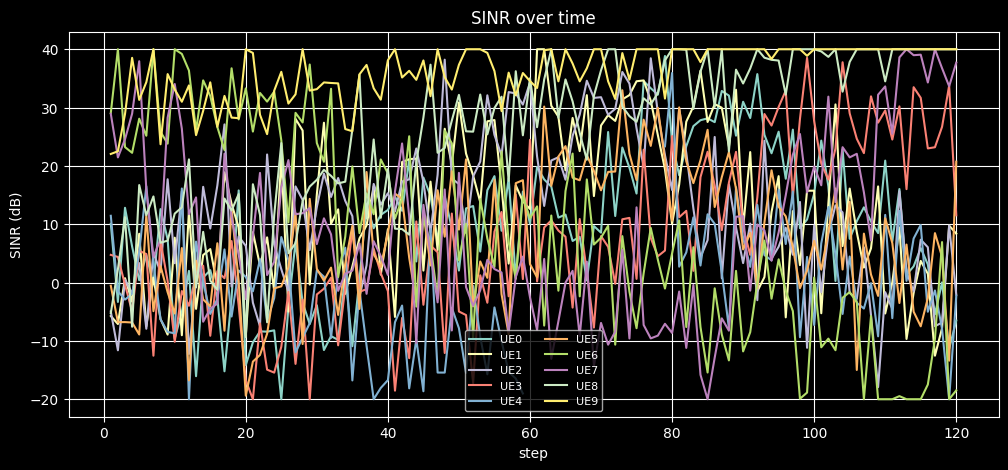

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

for ue_id in sorted(df["ue_id"].unique()):
    d = df[df["ue_id"] == ue_id].sort_values("step")
    ax.plot(d["step"], d["sinr"], linewidth=1.5, label=f"UE{ue_id}")

ax.set_title("SINR over time")
ax.set_xlabel("step")
ax.set_ylabel("SINR (dB)")
ax.grid(True)
ax.legend(ncol=2, fontsize=8)
plt.show()

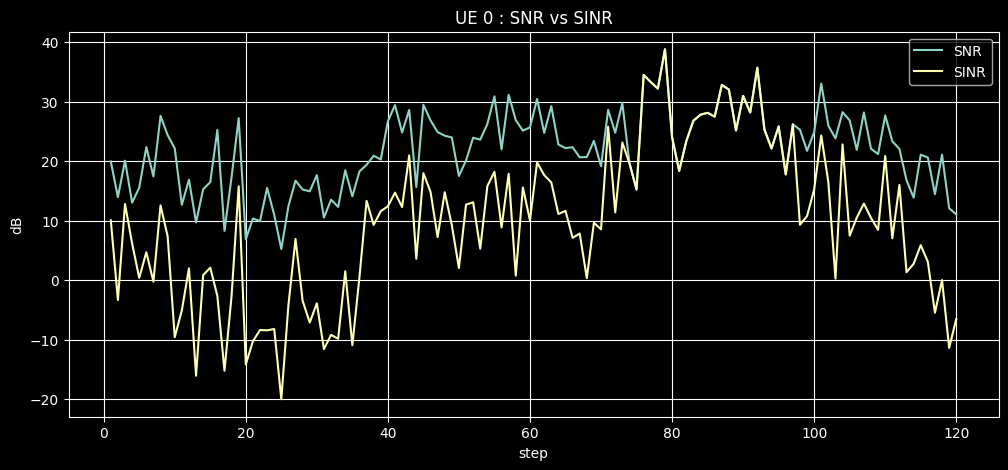

In [17]:
ue_id = 0
d = df[df["ue_id"] == ue_id].sort_values("step")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(d["step"], d["snr"], label="SNR")
ax.plot(d["step"], d["sinr"], label="SINR")
ax.set_title(f"UE {ue_id} : SNR vs SINR")
ax.set_xlabel("step")
ax.set_ylabel("dB")
ax.grid(True)
ax.legend()
plt.show()

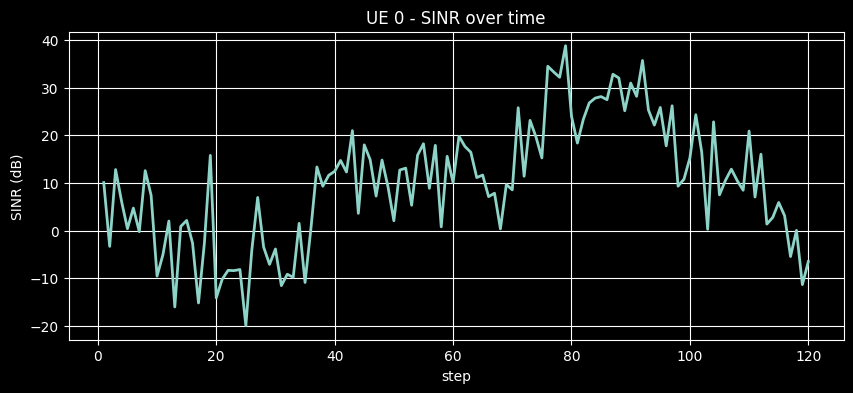

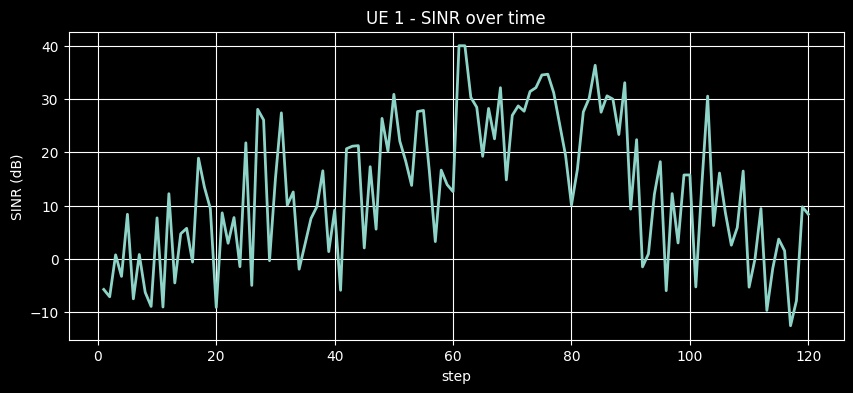

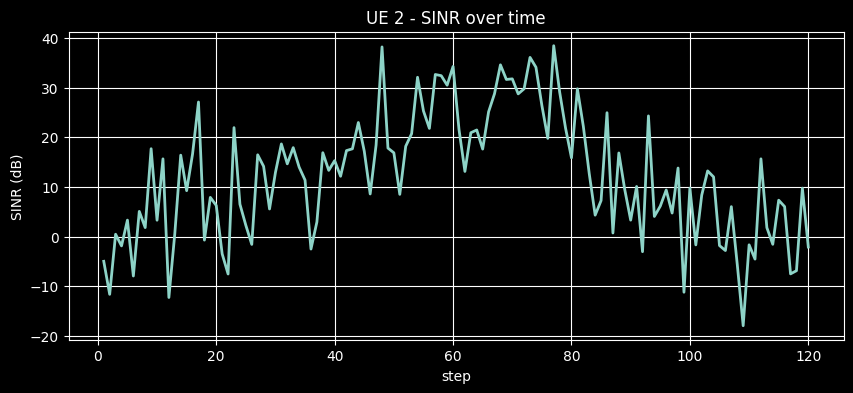

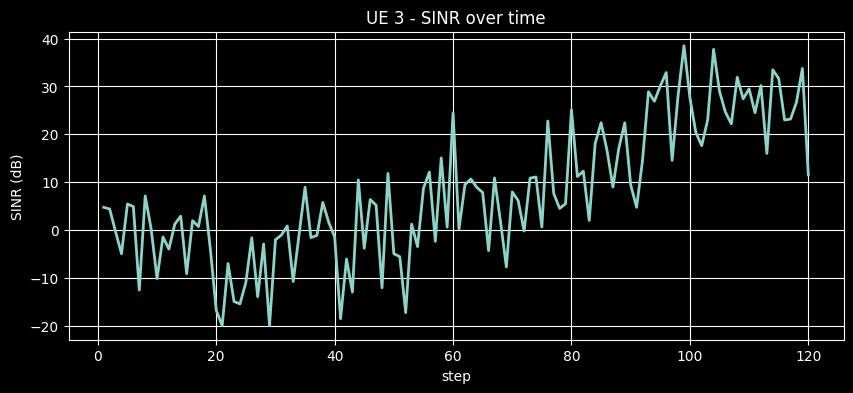

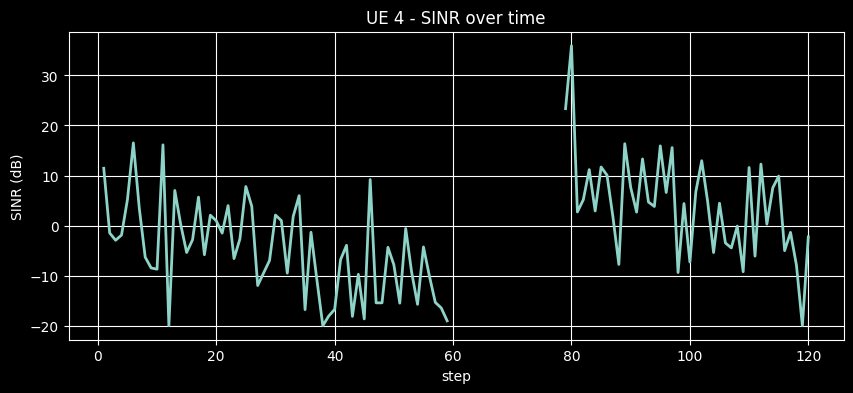

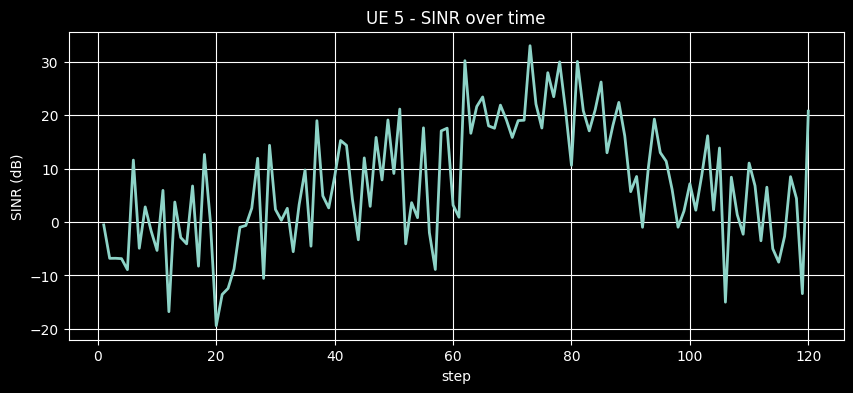

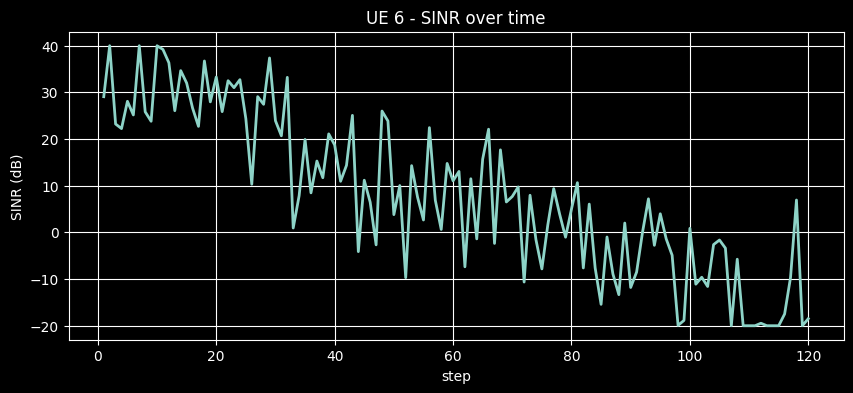

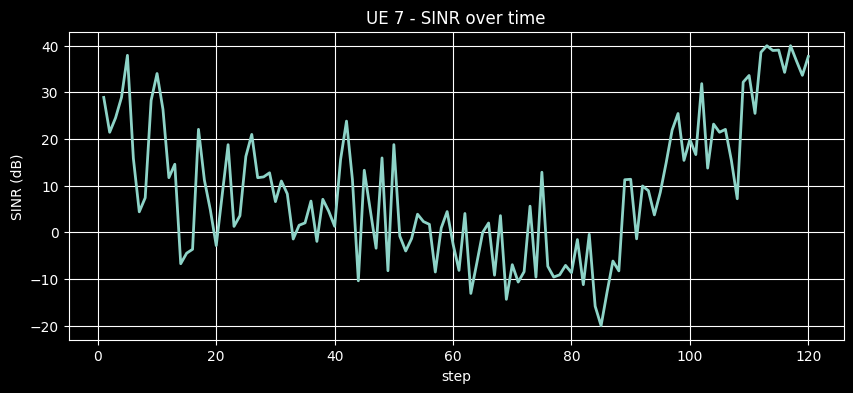

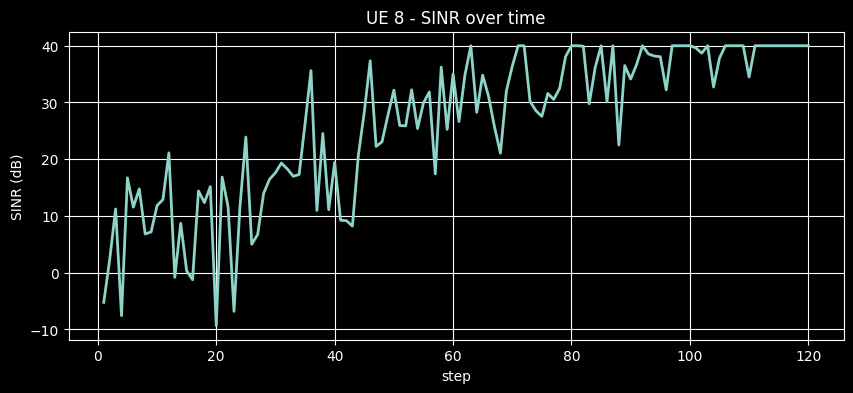

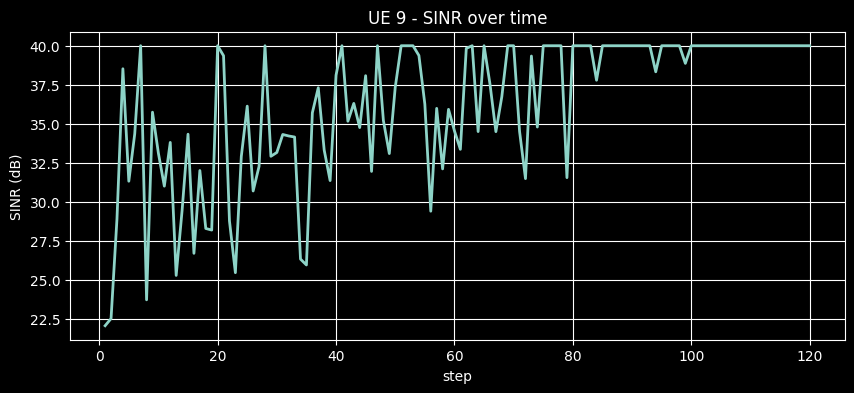

In [18]:
import matplotlib.pyplot as plt

for ue_id in sorted(df["ue_id"].unique()):
    d = df[df["ue_id"] == ue_id].sort_values("step")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(d["step"], d["sinr"], linewidth=2)

    ax.set_title(f"UE {ue_id} - SINR over time")
    ax.set_xlabel("step")
    ax.set_ylabel("SINR (dB)")
    ax.grid(True)

    plt.show()

In [19]:
import numpy as np

# Reset env
obs, info = env.reset(seed=42)

# Add controlled UEs (different demand levels)
env.add_ue(x=300, y=200, vx=0, vy=0, slice_type="eMBB", bit_rate=2_000_000)  # high demand
env.add_ue(x=320, y=220, vx=0, vy=0, slice_type="eMBB", bit_rate=1_000_000)  # medium
env.add_ue(x=350, y=250, vx=0, vy=0, slice_type="eMBB", bit_rate=200_000)    # low
env.add_ue(x=400, y=300, vx=0, vy=0, slice_type="eMBB", bit_rate=0)          # no demand

# Run one step
action = env.action_space.sample()
obs, reward, terminated, truncated, info = env.step(action)

print("\n=== PRB ALLOCATION TEST ===")

for gnb in env.gnbs:
    print(f"\n🔵 gNB {gnb.id}")
    print(f"Total PRBs: {gnb.n_prbs}")

    attached = [ue for ue in env.get_all_ues() if ue.serving_gnb == gnb.id]

    total_used = 0

    for ue in attached:
        print(f"  UE {ue.id}:")
        print(f"    queue: {ue.queue:.2f}")
        print(f"    SINR: {ue.e_sinr:.2f} dB")
        print(f"    PRBs allocated: {ue.prbs}")
        print(f"    throughput: {ue.th:.2f}")
        total_used += ue.prbs

    print(f"➡️ Total PRBs used: {total_used}")
    print(f"➡️ PRBs remaining: {gnb.n_prbs - total_used}")


=== PRB ALLOCATION TEST ===

🔵 gNB 0
Total PRBs: 150
  UE 10:
    queue: 0.00
    SINR: 7.76 dB
    PRBs allocated: 44
    throughput: 443715.77
  UE 11:
    queue: 0.00
    SINR: 11.92 dB
    PRBs allocated: 16
    throughput: 233510.94
➡️ Total PRBs used: 60
➡️ PRBs remaining: 90

🔵 gNB 1
Total PRBs: 150
  UE 0:
    queue: 10994590.00
    SINR: 2.81 dB
    PRBs allocated: 0
    throughput: 97.43
  UE 1:
    queue: 15471674.00
    SINR: -11.97 dB
    PRBs allocated: 62
    throughput: 20478.90
  UE 2:
    queue: 9887202.00
    SINR: 0.84 dB
    PRBs allocated: 0
    throughput: 219.30
  UE 3:
    queue: 0.00
    SINR: 1.42 dB
    PRBs allocated: 88
    throughput: 397876.84
  UE 5:
    queue: 14262468.00
    SINR: -2.65 dB
    PRBs allocated: 0
    throughput: 662.16
  UE 13:
    queue: 0.00
    SINR: 1.63 dB
    PRBs allocated: 0
    throughput: 0.00
➡️ Total PRBs used: 150
➡️ PRBs remaining: 0

🔵 gNB 2
Total PRBs: 150
  UE 12:
    queue: 0.00
    SINR: -8.89 dB
    PRBs allocated: 

In [20]:
import pandas as pd

rows = []

obs, info = env.reset(seed=42)

n_steps = 100

for step in range(n_steps):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    for gnb in env.gnbs:
        attached = [ue for ue in env.get_all_ues() if ue.serving_gnb == gnb.id]

        used_prbs = sum(ue.prbs for ue in attached)
        total_prbs = gnb.n_prbs
        free_prbs = total_prbs - used_prbs

        rows.append({
            "step": step,
            "gnb_id": gnb.id,
            "used_prbs": used_prbs,
            "free_prbs": free_prbs,
            "total_prbs": total_prbs,
            "n_users": len(attached),
        })

    if terminated or truncated:
        break

df_prb = pd.DataFrame(rows)

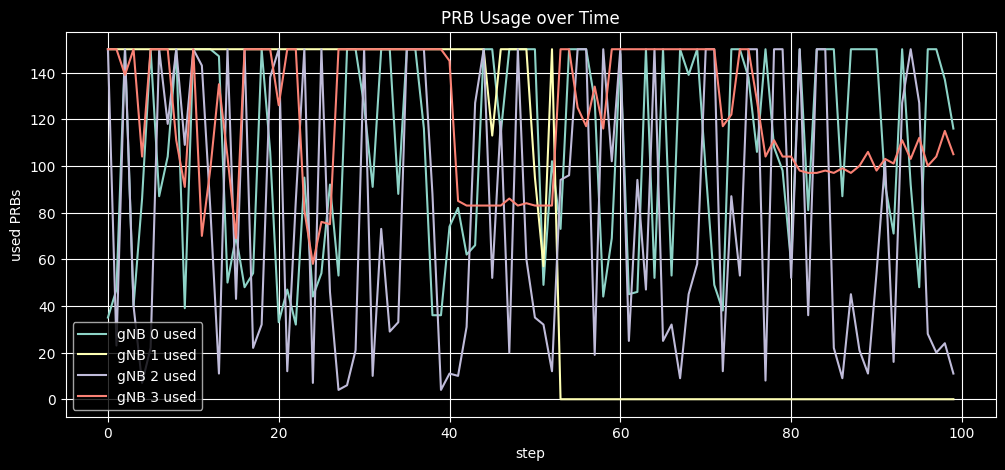

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

for gnb_id in sorted(df_prb["gnb_id"].unique()):
    d = df_prb[df_prb["gnb_id"] == gnb_id]
    ax.plot(d["step"], d["used_prbs"], label=f"gNB {gnb_id} used")

ax.set_title("PRB Usage over Time")
ax.set_xlabel("step")
ax.set_ylabel("used PRBs")
ax.grid(True)
ax.legend()
plt.show()

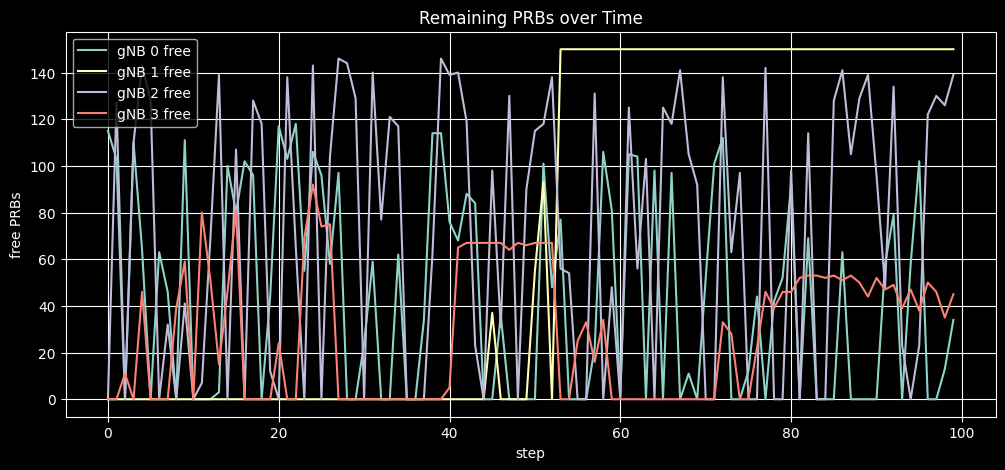

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

for gnb_id in sorted(df_prb["gnb_id"].unique()):
    d = df_prb[df_prb["gnb_id"] == gnb_id]
    ax.plot(d["step"], d["free_prbs"], label=f"gNB {gnb_id} free")

ax.set_title("Remaining PRBs over Time")
ax.set_xlabel("step")
ax.set_ylabel("free PRBs")
ax.grid(True)
ax.legend()
plt.show()

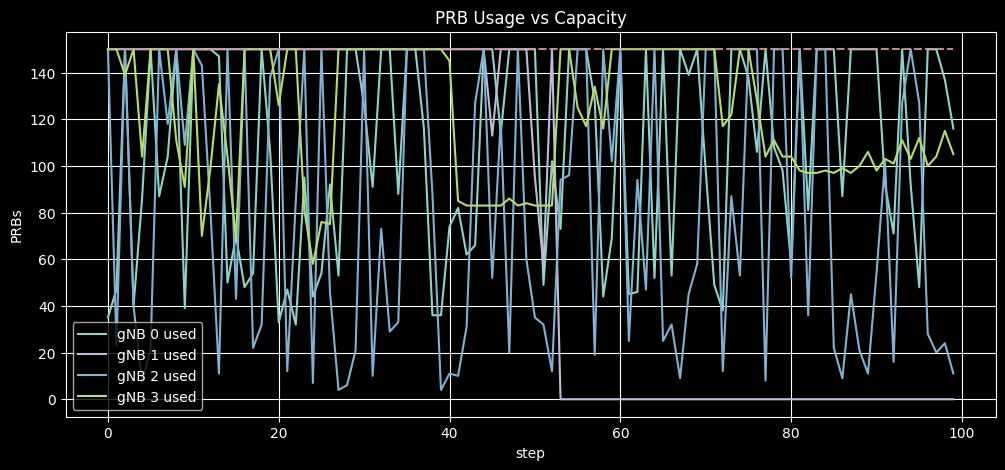

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

for gnb_id in sorted(df_prb["gnb_id"].unique()):
    d = df_prb[df_prb["gnb_id"] == gnb_id]

    ax.plot(d["step"], d["used_prbs"], label=f"gNB {gnb_id} used")
    ax.plot(d["step"], d["total_prbs"], linestyle="--", alpha=0.4)

ax.set_title("PRB Usage vs Capacity")
ax.set_xlabel("step")
ax.set_ylabel("PRBs")
ax.grid(True)
ax.legend()
plt.show()

In [24]:
import pandas as pd
import numpy as np

rows = []
obs, info = env.reset(seed=123)

n_steps = 120

for step in range(n_steps):
    scores_before = {ue.id: env._compute_ue_badness(ue) for ue in env.get_all_ues()}
    worst_before = max(scores_before, key=scores_before.get)

    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    for ue in env.get_all_ues():
        metrics = env.get_ue_radio_metrics(ue.id)
        rows.append({
            "step": step + 1,
            "ue_id": ue.id,
            "x": float(ue.x),
            "y": float(ue.y),
            "vx": float(ue.vx),
            "vy": float(ue.vy),
            "serving_gnb": -1 if ue.serving_gnb is None else int(ue.serving_gnb),
            "connected": int(bool(ue.connected)),
            "sinr": float(metrics["sinr_db"]) if np.isfinite(metrics["sinr_db"]) else np.nan,
            "snr": float(metrics["snr_db"]) if np.isfinite(metrics["snr_db"]) else np.nan,
            "interference_dbm": float(metrics["interference_dbm"]) if np.isfinite(metrics["interference_dbm"]) else np.nan,
            "queue": float(ue.queue),
            "throughput": float(ue.th),
            "wait_time": float(ue.wait_time),
            "prbs": float(ue.prbs),   # <- important
            "bits": float(ue.bits),
            "ho_pending": int(bool(ue.ho_pending)),
            "badness": float(env._compute_ue_badness(ue)),
            "acted_ue_id": info.get("acted_ue_id"),
            "next_control_ue_id": info.get("next_control_ue_id"),
            "worst_before": worst_before,
            "reward": float(reward),
        })

    if terminated or truncated:
        print("Episode ended at step", step + 1)
        break

df = pd.DataFrame(rows)

print(df.columns.tolist())
display(df.head())

['step', 'ue_id', 'x', 'y', 'vx', 'vy', 'serving_gnb', 'connected', 'sinr', 'snr', 'interference_dbm', 'queue', 'throughput', 'wait_time', 'prbs', 'bits', 'ho_pending', 'badness', 'acted_ue_id', 'next_control_ue_id', 'worst_before', 'reward']


,step,ue_id,x,y,vx,vy,serving_gnb,connected,sinr,snr,...,throughput,wait_time,prbs,bits,ho_pending,badness,acted_ue_id,next_control_ue_id,worst_before,reward
0,1,0,1874.0,357.6,7.0,0.8,3,1,21.773490,21.773490,...,229820.860000,1.0,9.0,11491043.0,0,17.701791,13,12,13,0.3
1,1,1,1873.0,406.4,6.5,1.2,3,1,32.176774,32.176774,...,345708.633977,1.0,12.0,17280000.0,0,16.542914,13,12,13,0.3
2,1,2,1852.0,331.0,6.0,0.5,3,1,27.749352,27.749352,...,201627.204800,1.0,7.0,10080000.0,0,17.983728,13,12,13,0.3
3,1,3,1571.0,209.0,5.5,-0.5,3,1,38.803600,38.803600,...,403565.824311,1.0,14.0,20160000.0,0,15.964342,13,12,13,0.3
4,1,4,1979.6,138.0,6.8,-1.0,3,1,24.410190,24.410190,...,254797.185918,1.0,16.0,12725208.0,0,362.804908,13,12,13,0.3


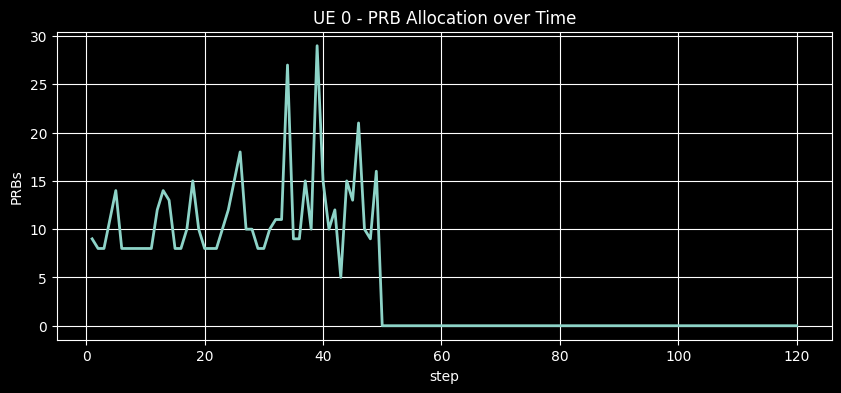

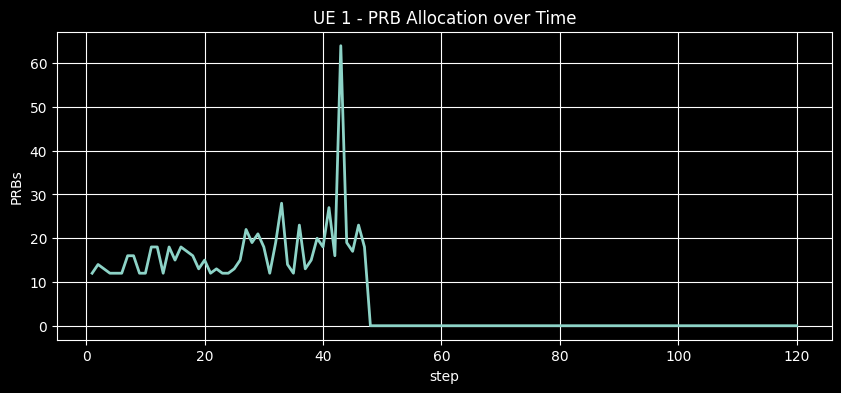

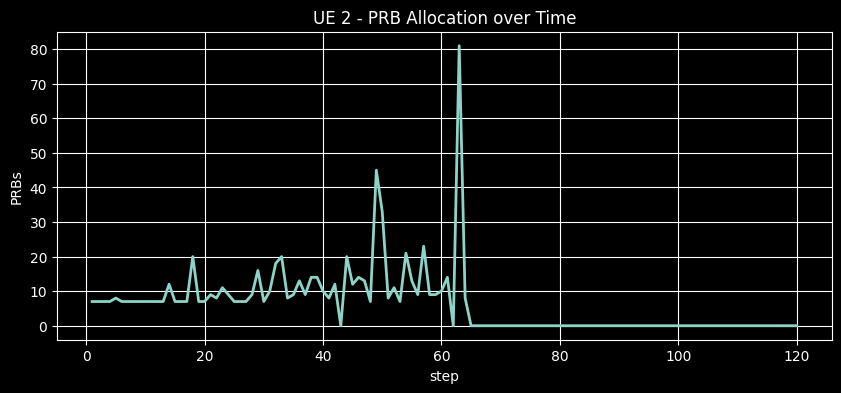

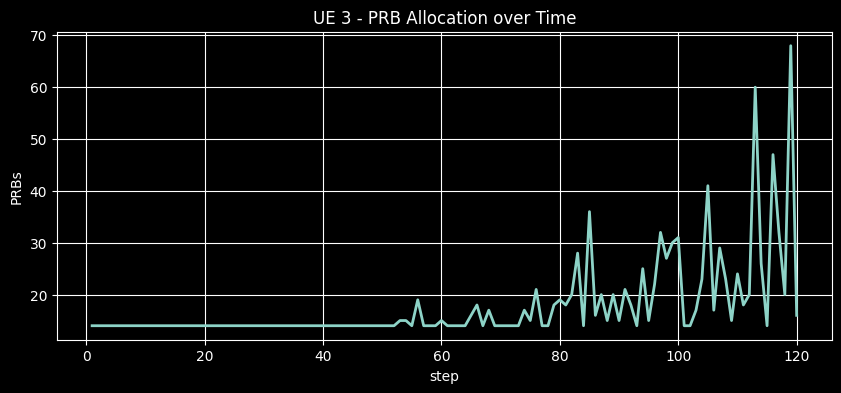

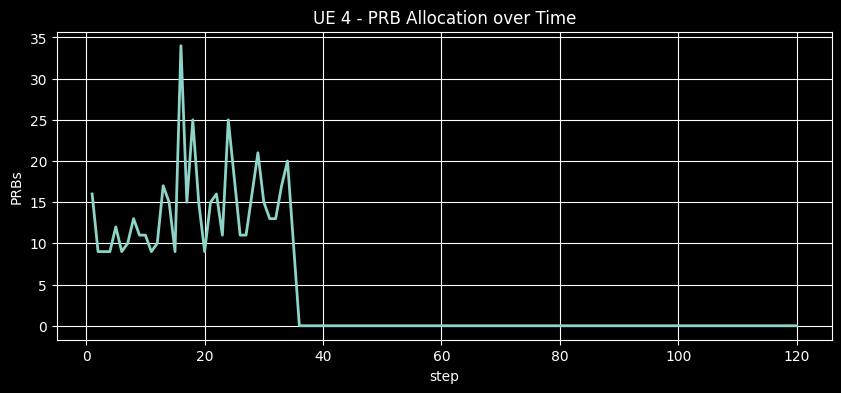

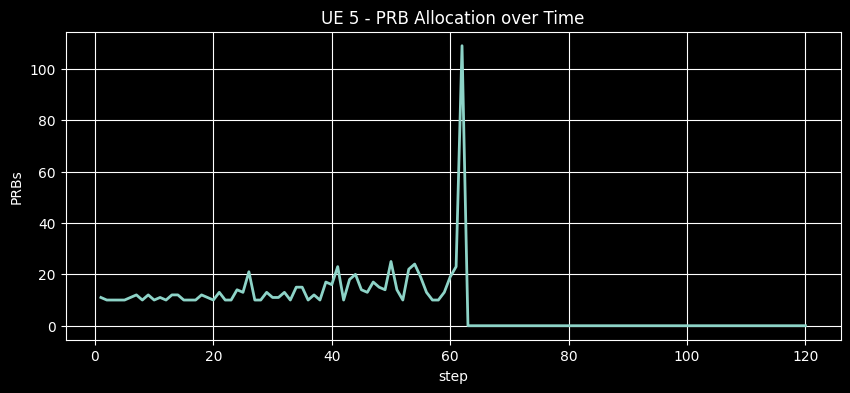

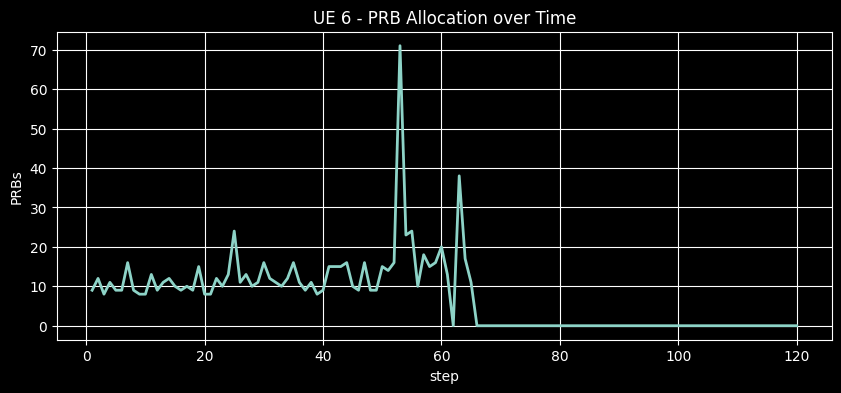

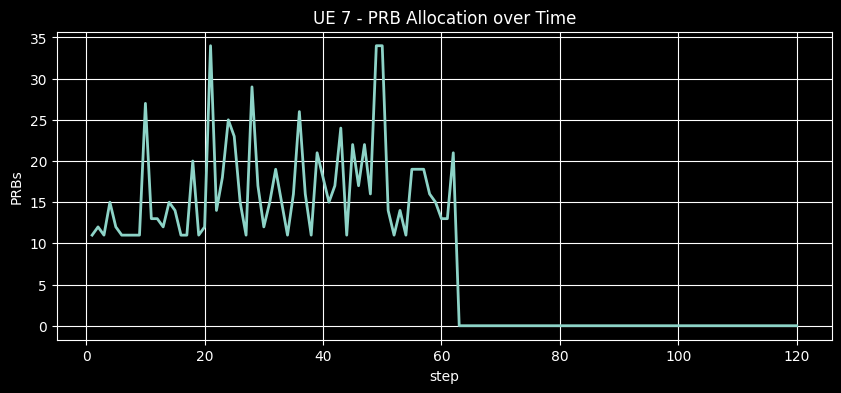

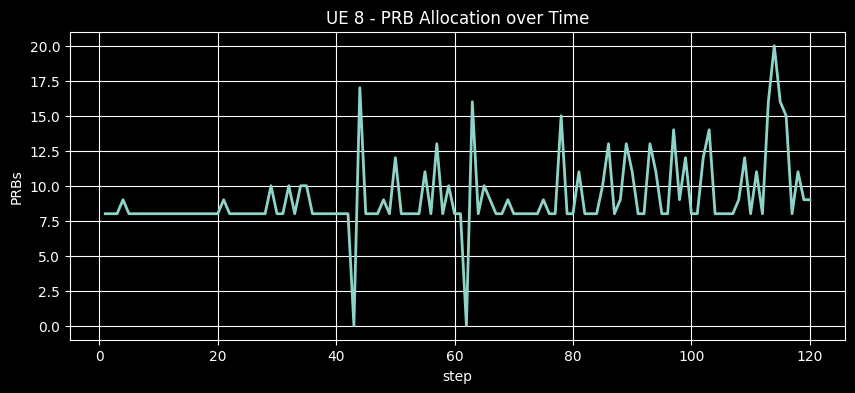

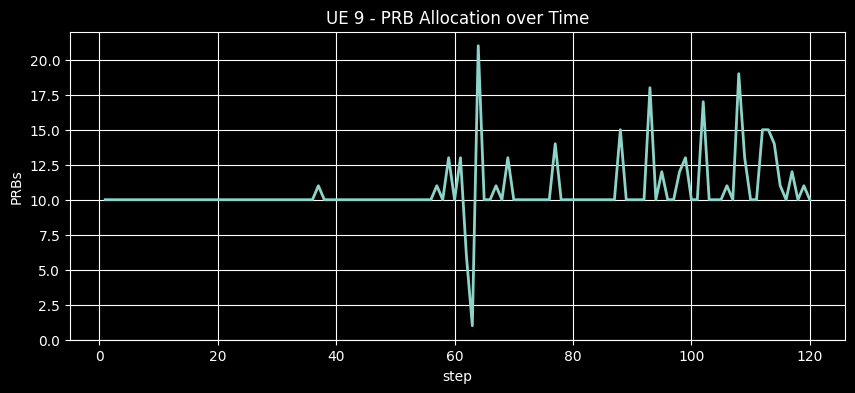

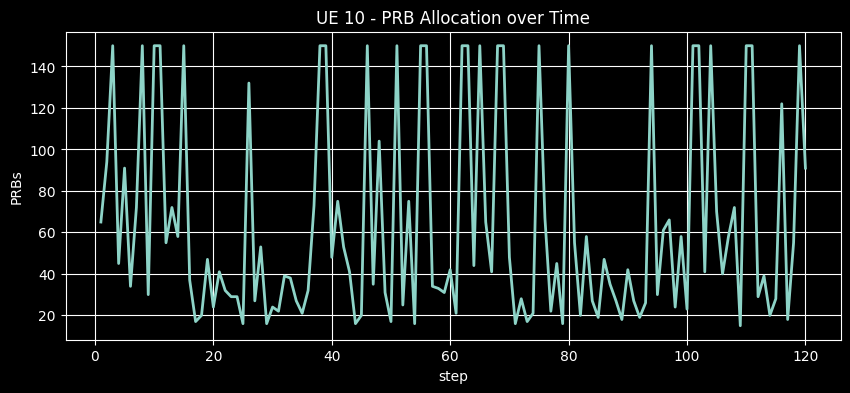

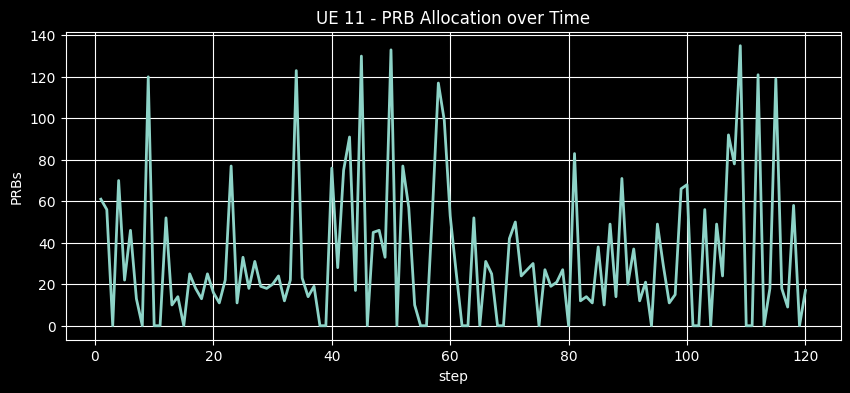

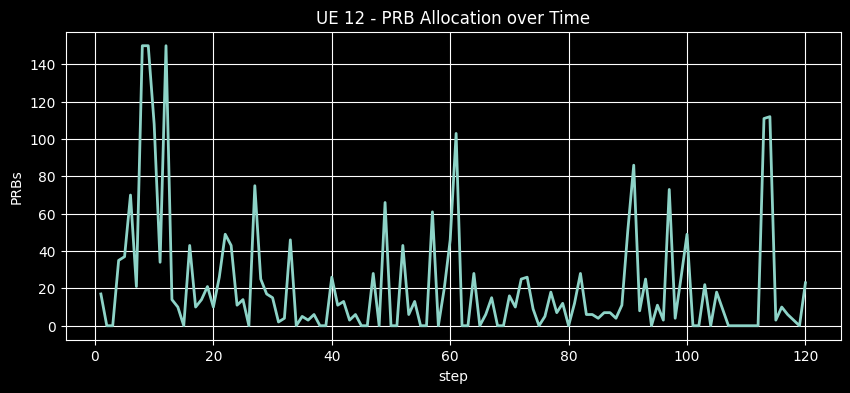

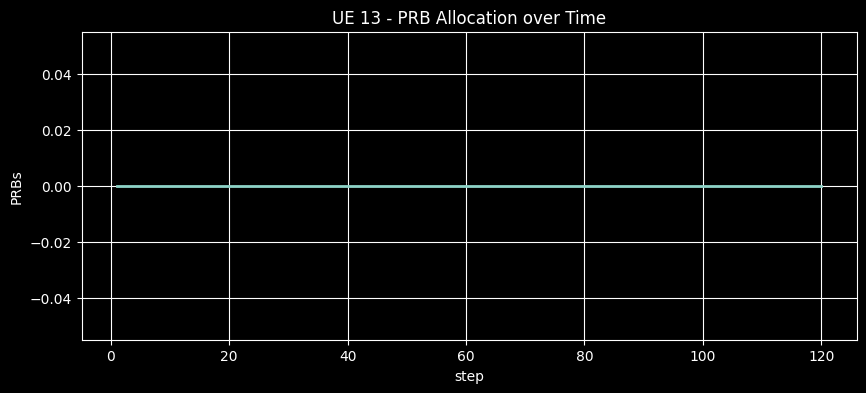

In [25]:
import matplotlib.pyplot as plt

for ue_id in sorted(df["ue_id"].unique()):
    d = df[df["ue_id"] == ue_id].sort_values("step")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(d["step"], d["prbs"], linewidth=2)

    ax.set_title(f"UE {ue_id} - PRB Allocation over Time")
    ax.set_xlabel("step")
    ax.set_ylabel("PRBs")
    ax.grid(True)

    plt.show()

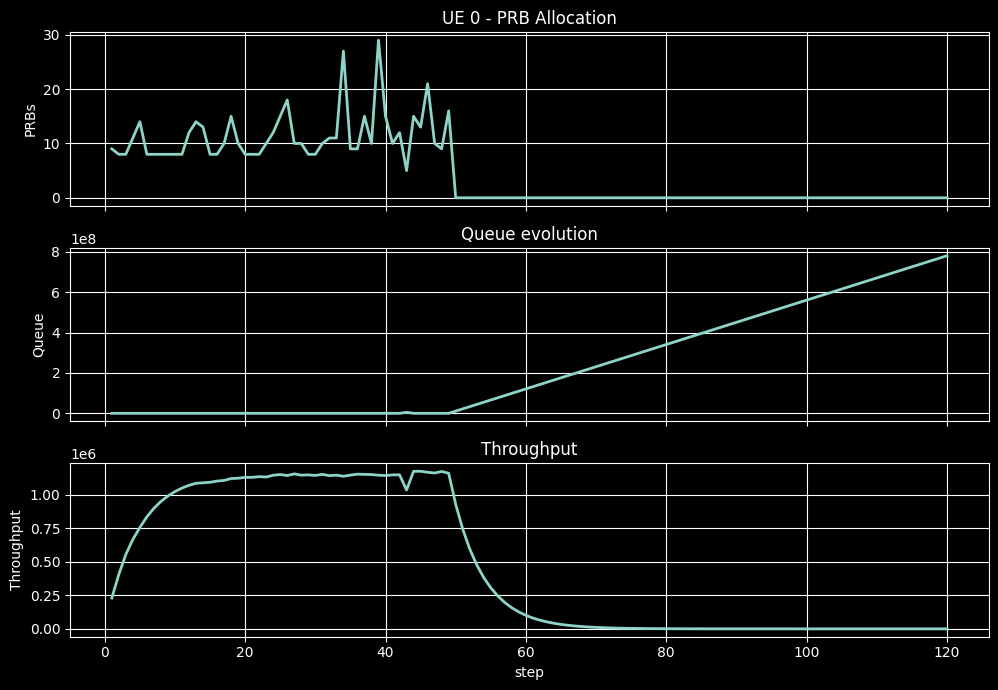

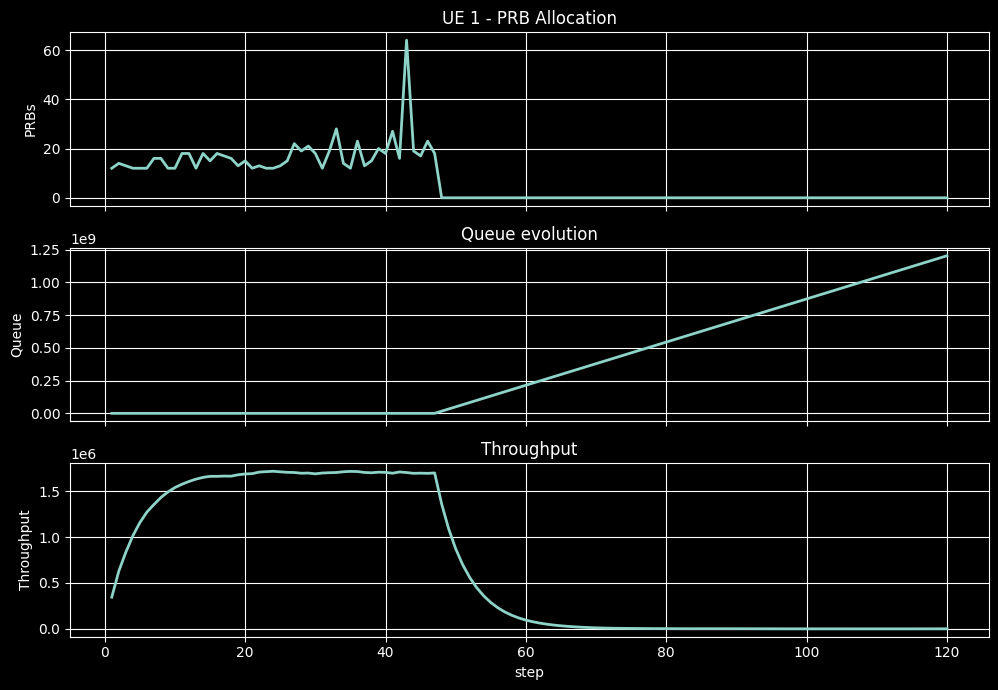

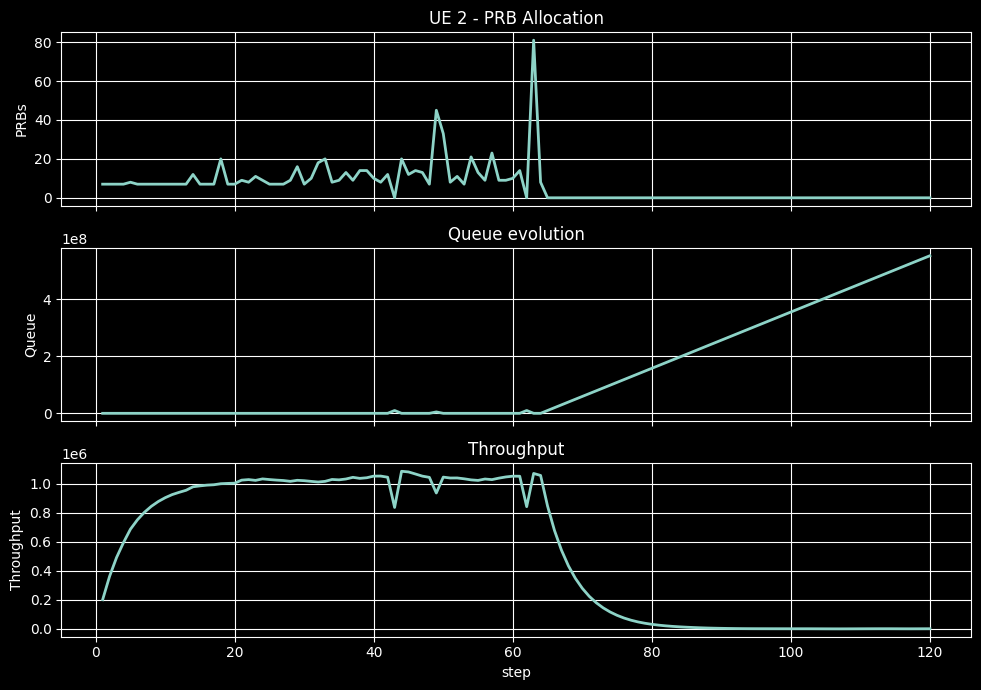

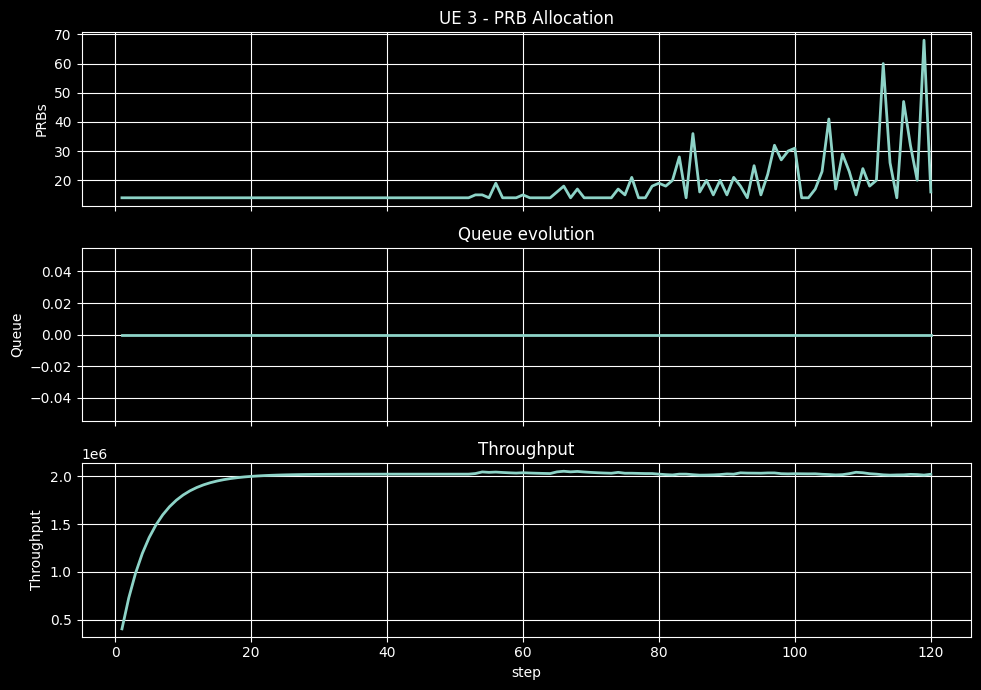

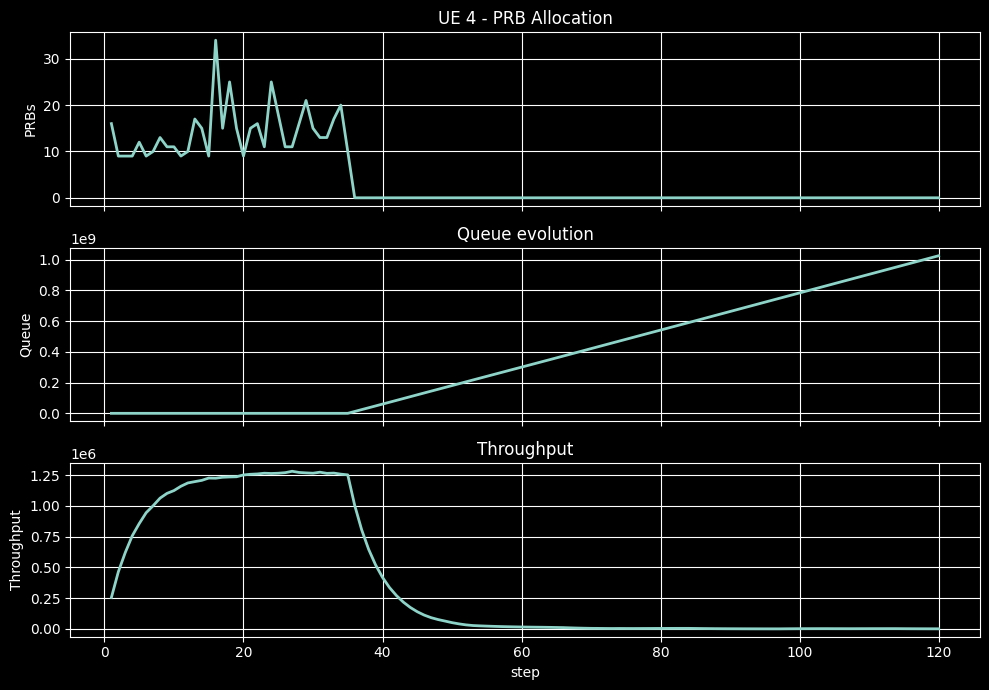

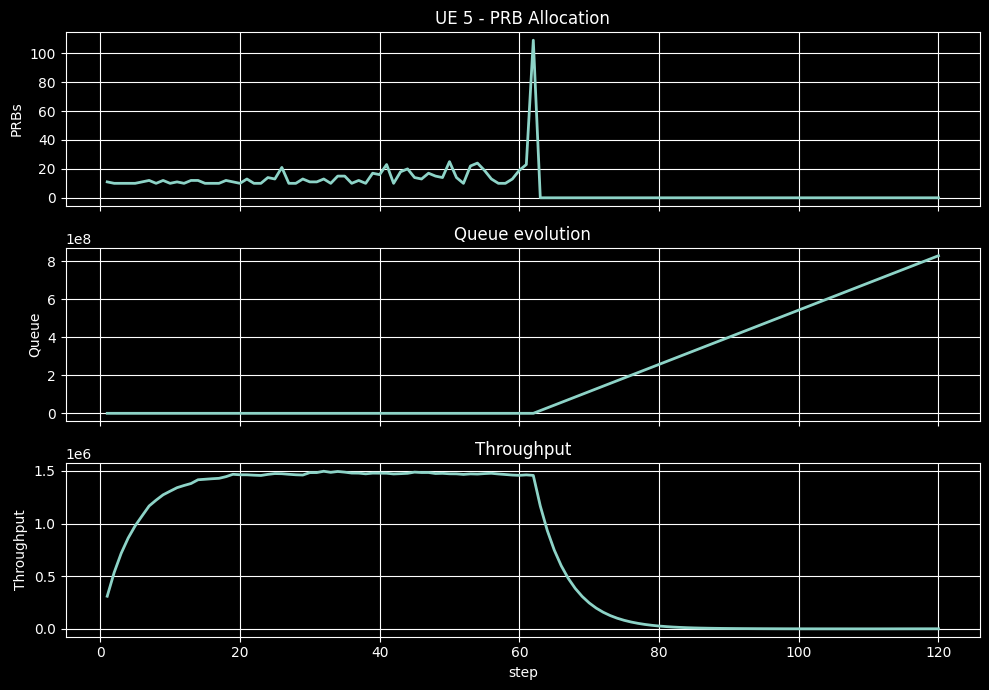

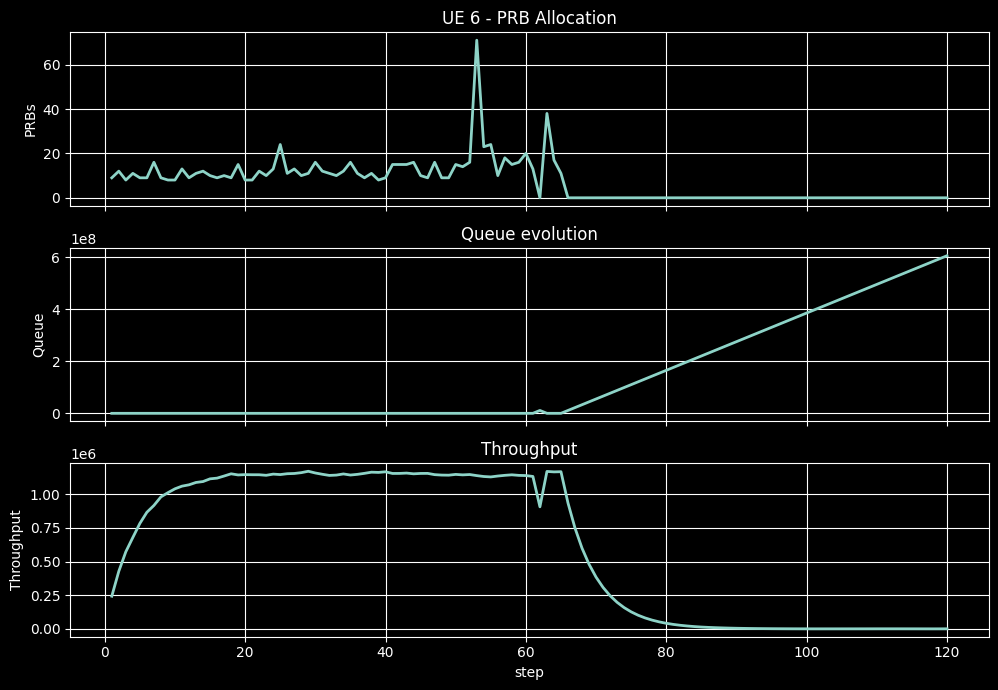

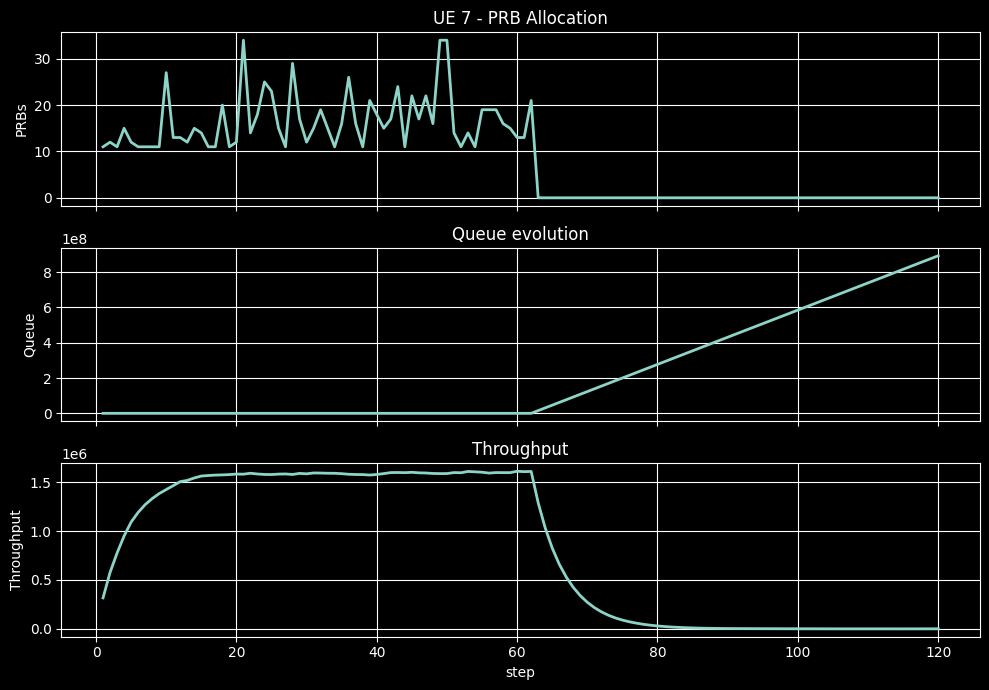

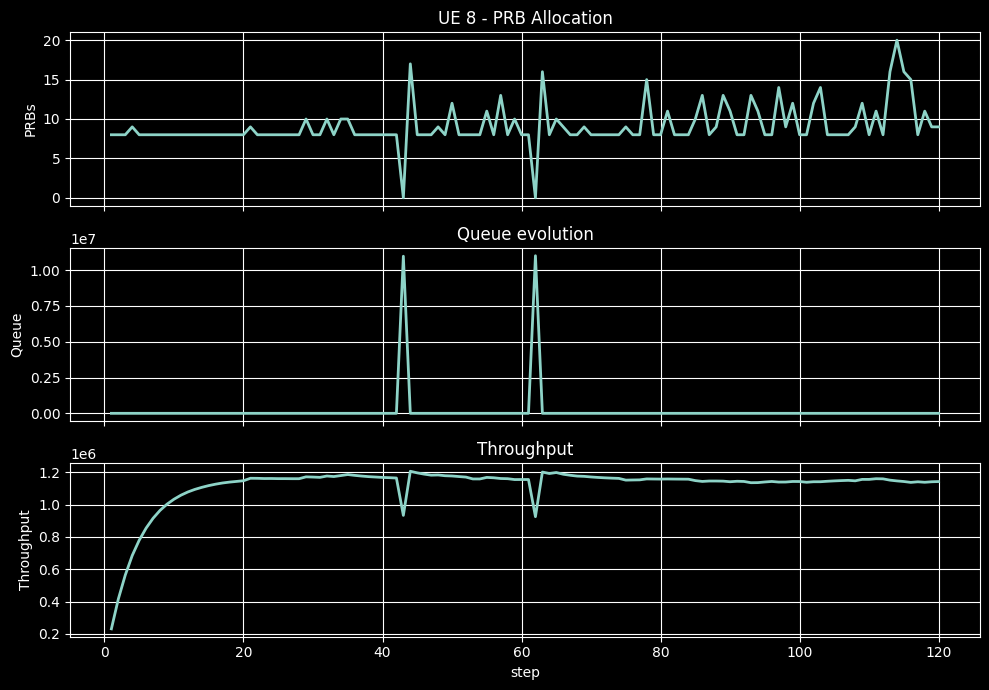

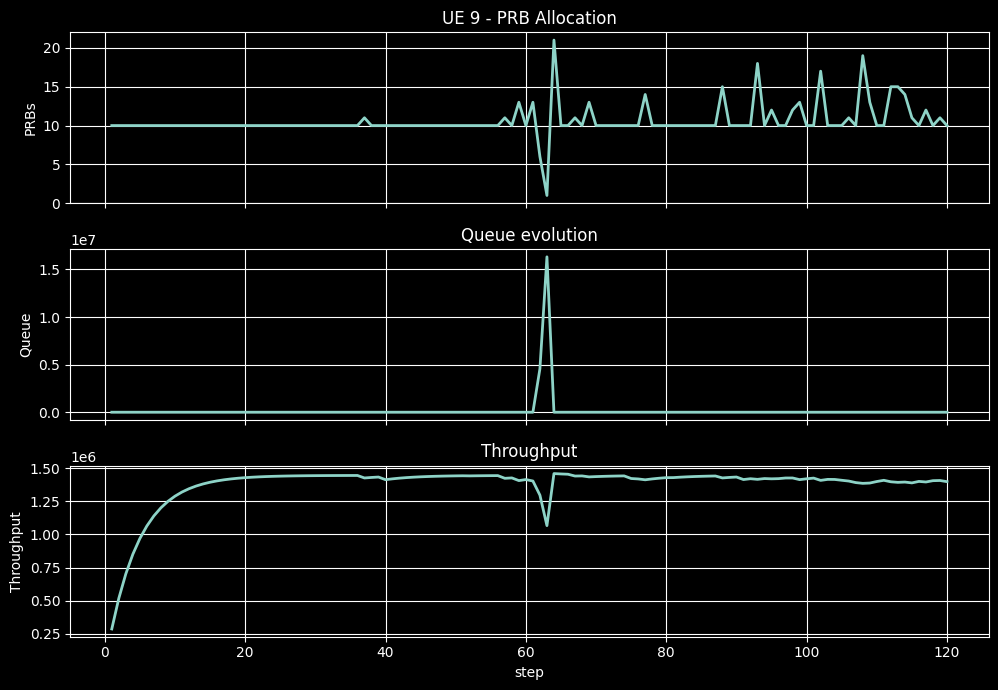

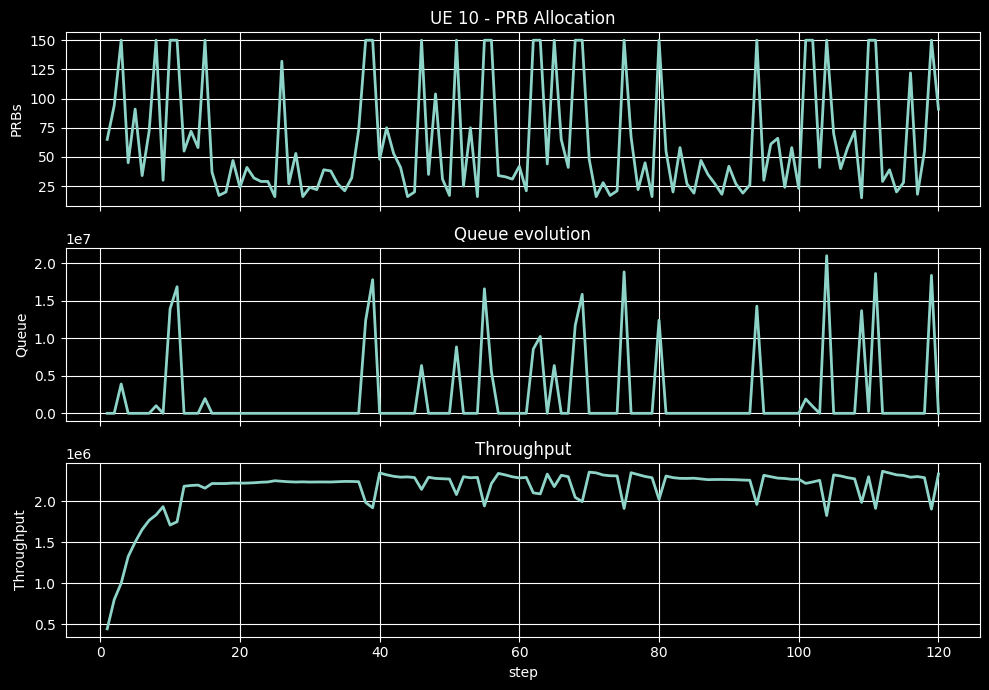

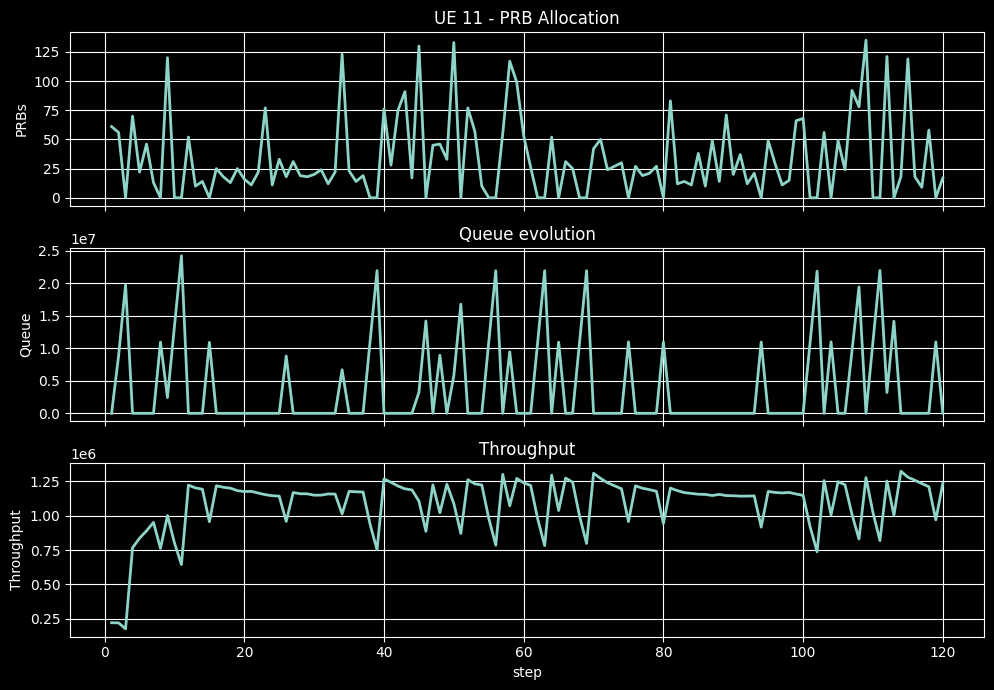

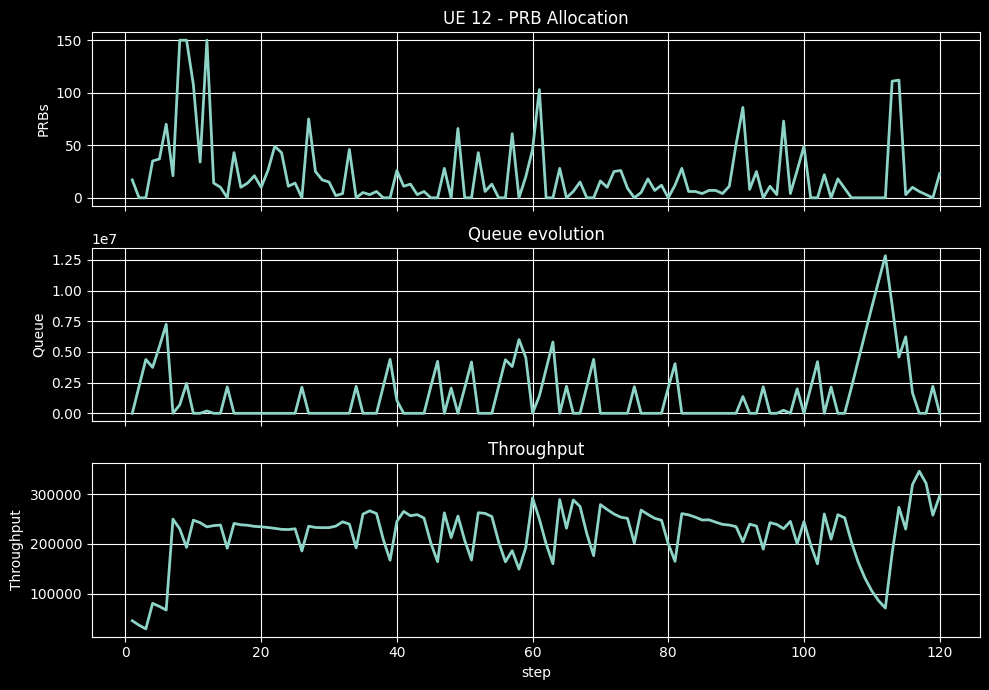

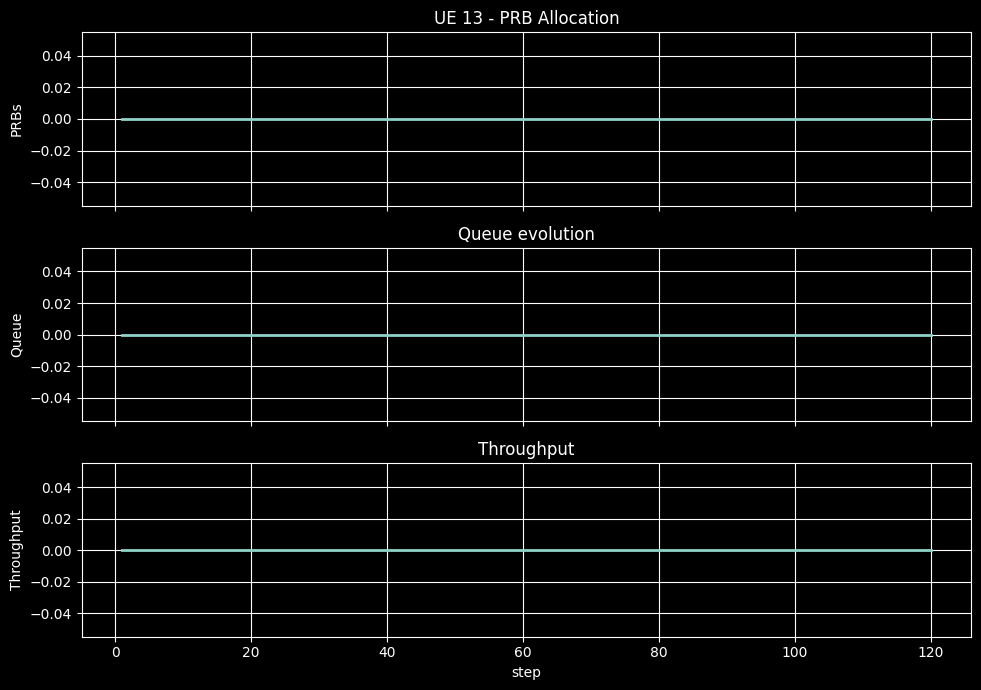

In [26]:
for ue_id in sorted(df["ue_id"].unique()):
    d = df[df["ue_id"] == ue_id].sort_values("step")

    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

    # --- PRBs ---
    axes[0].plot(d["step"], d["prbs"], linewidth=2)
    axes[0].set_ylabel("PRBs")
    axes[0].set_title(f"UE {ue_id} - PRB Allocation")
    axes[0].grid(True)

    # --- Queue ---
    axes[1].plot(d["step"], d["queue"], linewidth=2)
    axes[1].set_ylabel("Queue")
    axes[1].set_title("Queue evolution")
    axes[1].grid(True)

    # --- Throughput ---
    axes[2].plot(d["step"], d["throughput"], linewidth=2)
    axes[2].set_ylabel("Throughput")
    axes[2].set_xlabel("step")
    axes[2].set_title("Throughput")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

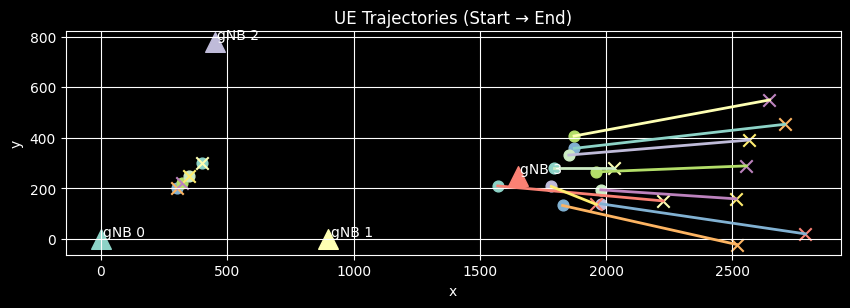

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Plot gNBs
for gnb in env.gnbs:
    ax.scatter(gnb.x, gnb.y, s=200, marker="^")
    ax.text(gnb.x + 10, gnb.y + 10, f"gNB {gnb.id}")

# Plot UE trajectories
for ue_id in sorted(df["ue_id"].unique()):
    d = df[df["ue_id"] == ue_id].sort_values("step")

    ax.plot(d["x"], d["y"], linewidth=2)
    ax.scatter(d["x"].iloc[0], d["y"].iloc[0], s=60)  # start
    ax.scatter(d["x"].iloc[-1], d["y"].iloc[-1], s=80, marker="x")  # end

ax.set_title("UE Trajectories (Start → End)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
ax.set_aspect("equal")

plt.show()

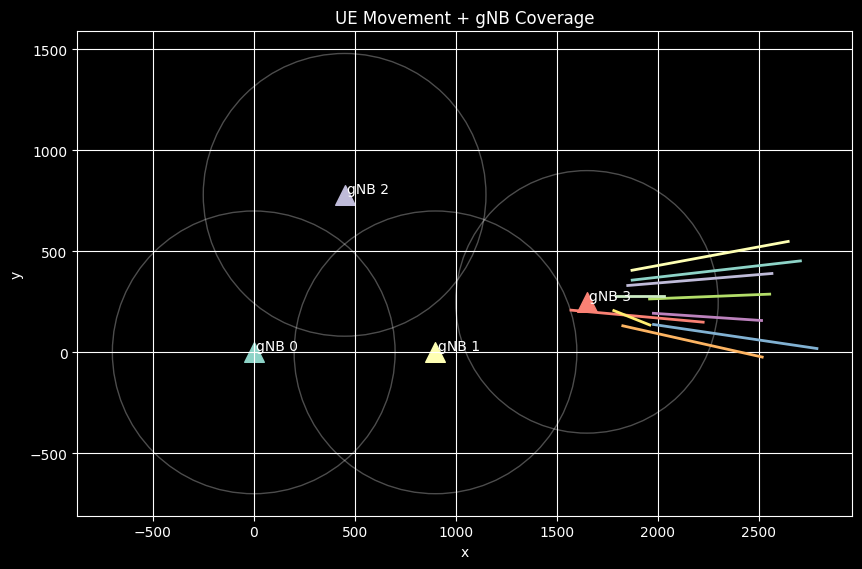

In [28]:
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(10, 8))

# gNBs + coverage
for gnb in env.gnbs:
    ax.scatter(gnb.x, gnb.y, s=200, marker="^")
    ax.add_patch(Circle((gnb.x, gnb.y), gnb.coverage_radius, fill=False, alpha=0.3))
    ax.text(gnb.x + 10, gnb.y + 10, f"gNB {gnb.id}")

# UE paths
for ue_id in sorted(df["ue_id"].unique()):
    d = df[df["ue_id"] == ue_id].sort_values("step")
    ax.plot(d["x"], d["y"], linewidth=2)

ax.set_title("UE Movement + gNB Coverage")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
ax.set_aspect("equal")

plt.show()